# `geoai-datacubes` -- Land-cover classification end-to-end

<a href="https://colab.research.google.com/github/buckai-observatory/geoai-datacubes/blob/main/notebooks/01_classification.ipynb" target="_blank" rel="noopener noreferrer"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>


**Welcome!** This is the second pedagogical notebook in the `geoai-datacubes`
series. The first notebook (`00_geoai_datacubes_tour.ipynb`) walks you through
the **data acquisition** side: how to fetch multi-mission satellite imagery
(Sentinel-2 + Sentinel-1 + Landsat + Copernicus DEM + ESA WorldCover), fuse the
missions onto a common UTM grid, tile, split, and inspect metadata.

This notebook picks up where the tour leaves off and shows the **machine-learning
and deep-learning** half of a real geospatial workflow on the same kind of data cube.
We train and compare four standard classifiers for the same target -- *is this
pixel permanent water?* -- and walk through everything a new BuckAI Observatory
grad student / postdoc / faculty member would need to do their first
remote-sensing ML/DL project:

1. **Wrap a multi-band satellite cube in a PyTorch `Dataset` without writing
 any tile files to disk** (using the new `LazyTileDataset` helper).
2. **Build a meaningful binary-classification target** from a freely-available
 ground-truth layer (ESA WorldCover LULC class 80 = permanent water bodies
 -> 1; everything else -> 0).
3. **Train and compare four classifiers**: Logistic Regression, Random Forest,
 XGBoost, and a lightweight U-Net (PyTorch).
4. **Quantify why multi-modal fusion matters** -- concrete metric lifts going
 from `S2-only` -> `S2+S1` -> `S2+S1+DEM` for the water target.
5. **Test cross-city generalisation** -- train on Columbus, validate on
 Cincinnati, test on Cleveland. The three cities expose the model to very
 different water contexts: the narrow Scioto River, the broader Ohio River,
 and the open expanse of Lake Erie.
6. **Walk through standard ML/DL diagnostics** -- confusion matrices, ROC curves,
 F1 / IoU / precision / recall, learning curves, tree-model feature
 importance, and per-pixel U-Net prediction overlays.

The notebook is self-contained and Colab-launchable: it fetches its own
scenes, fuses them, converts to Zarr, trains four models, and evaluates --
no dependency on having run notebook 00. End-to-end runtime on a Colab CPU
is around 5-10 minutes.

> *Why water?* Surface-water mapping is the textbook "first segmentation task"
> in remote sensing. Water has a clear physical signature in every modality we
> fuse (dark in SAR, low-lying in DEM, distinctive S2 spectrum), so the story
> of multi-modal fusion shows up cleanly in the metrics. It is also useful
> in practice: flood mapping, reservoir monitoring, and Great Lakes
> water-level tracking all start with exactly this binary mask.

One more important note: this notebook on putting together your first ML/DL models is for illustrative and educational purposes only. You should not necessarily expect excellent performance results, especially for harder classes like croplands. A true scientific ML/DL workflow would use more training data, perhaps larger tiles (we use 64x64 pixels here), explore additional pre-processing steps to enhance performance (e.g., how to best normalize multimodal inputs for a DL model), use deeper DL/CNN/U-Net-type models with more parameters, and thus generally take much longer to run. Such models would also typically be run on a GPU, which is more efficient than CPUs for ML/DL, while this example notebook can easily run on a laptop/desktop CPU or free cloud node (like Colab).

## 1. Setup

The first few cells handle environment bootstrapping. On Colab they clone
the repo and install the handful of packages Colab does not ship with by
default; locally they are no-ops that just confirm the layout.


In [1]:
# --- Colab / local bootstrap ---
# On Colab, this cell clones the repo and installs the few packages that are
# not in Colab's default runtime. On a local Jupyter run it is a no-op that
# just confirms the repo layout. Re-running it is safe.

import os
import subprocess
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Colab detected -- bootstrapping repo + dependencies")
    REPO_DIR = Path("/content/geoai-datacubes")
    if not REPO_DIR.exists():
        subprocess.check_call([
            "git", "clone", "--depth", "1",
            "https://github.com/buckai-observatory/geoai-datacubes.git",
            str(REPO_DIR),
        ])
    else:
        print(f"repo already cloned at {REPO_DIR}")

    # Colab pre-installs rasterio / shapely / scikit-image / scipy / tqdm /
    # pandas / pyproj / requests / matplotlib / scikit-learn / torch.
    # These extras may be missing for this notebook:
    missing = []
    for pkg, importname in [("python-dotenv", "dotenv"),
                            ("pystac",        "pystac"),
                            ("contextily",    "contextily"),
                            ("zarr",          "zarr"),
                            ("xgboost",       "xgboost")]:
        try:
            __import__(importname)
        except ImportError:
            missing.append(pkg)
    if missing:
        print(f"pip install -q {' '.join(missing)}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

    os.chdir(REPO_DIR / "notebooks")
    print(f"cwd = {os.getcwd()}")
else:
    print("Local environment -- using existing checkout")


Local environment -- using existing checkout


Load the standard scientific stack (numpy, matplotlib, pandas, torch, sklearn, xgboost) and put the pipeline modules under `geoai_datacubes/` on `sys.path`. We also create a scratch folder `notebooks/_ml_outputs/` for everything this notebook produces.


In [2]:
# --- imports + path setup ---
import os, sys, json, shutil, time, math, warnings, random
from pathlib import Path

# Keep CPU threading conservative: this notebook trains a tiny U-Net on a CPU
# while sklearn / xgboost run alongside, and an unbounded OMP/BLAS thread
# pool can deadlock with sklearn's joblib workers on macOS. Setting these
# BEFORE the heavy imports is the safe pattern.
os.environ.setdefault("OMP_NUM_THREADS",      "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS",      "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS",  "1")

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LightSource

# locate the repo root from this notebook's CWD (notebooks/)
NB_DIR = Path.cwd()
if NB_DIR.name != "notebooks":
    for p in (NB_DIR, *NB_DIR.parents):
        if (p / "notebooks").is_dir() and (p / "geoai_datacubes").is_dir():
            NB_DIR = p / "notebooks"
            break
REPO_ROOT = NB_DIR.parent
sys.path.insert(0, str(REPO_ROOT))

# Separate scratch folder for the ML notebook so we never collide with the
# tour notebook's _outputs/.
OUT   = NB_DIR / "_ml_outputs"
DATA  = OUT / "data"
FUSE  = OUT / "fused"
ZARR  = OUT / "zarr"
MODEL_CACHE_DIR = REPO_ROOT / "notebooks" / "sample_data" / "models"
for d in (OUT, DATA, FUSE, ZARR, MODEL_CACHE_DIR):
    d.mkdir(parents=True, exist_ok=True)

# nicer matplotlib defaults; cap dpi so the notebook stays well under 8 MB.
plt.rcParams["figure.dpi"]  = 100
plt.rcParams["savefig.dpi"] = 100
plt.rcParams["image.cmap"]  = "viridis"
plt.rcParams["axes.grid"]   = False
warnings.filterwarnings("ignore", category=UserWarning, module="rasterio")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Fixed seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Repo root :", REPO_ROOT)
print("Package   :", REPO_ROOT / "geoai_datacubes")
print("Outputs   :", OUT)


Repo root : /Users/moortgat/Documents/buckAI_observatory/Website/Github/geoai-datacubes
Package   : /Users/moortgat/Documents/buckAI_observatory/Website/Github/geoai-datacubes/geoai_datacubes
Outputs   : /Users/moortgat/Documents/buckAI_observatory/Website/Github/geoai-datacubes/notebooks/_ml_outputs


Import the four pipeline pieces this notebook uses throughout: `fetch_sentinel_data` for the per-mission STAC fetches, `fuse_response_tiffs` for multi-mission fusion onto a common grid, `LazyTileDataset` for on-the-fly PyTorch tile sampling, and `geotiff_to_zarr` for the Zarr re-pack.


In [3]:
# --- pipeline imports ---
from geoai_datacubes.fetch import resolve_aoi, fetch_sentinel_data, MISSION_PROFILES
from geoai_datacubes.preprocessing import (
    fuse_response_tiffs, LazyTileDataset, geotiff_to_zarr,
    # Band-meta-driven normalisation + index helpers (replace the inline
    # DEM_relative / NDVI / NDWI / StandardScaler ceremony further down).
    apply_band_norm, get_band_norm,
    compute_ndvi, compute_ndwi, compute_dem_gradient_magnitude,
)
from geoai_datacubes.viz.scenes import (
    stretch01, joint_rgb, downsample, find_response, find_band,
    show_bands, show_rgb,
)
from geoai_datacubes.ml_dl import (
    # Pixel-level + tile-level classification helpers used end-to-end
    # here AND by the benchmark_lulc_class.py / benchmark_unet_class.py
    # CLIs -- so the notebook and the cluster CLIs share one code path.
    harvest_pixels, balance_pos_neg, tune_threshold,
    binary_pixel_metrics, predict_with_threshold, full_metrics,
    class_filtered_indices, pick_class_balanced_tiles,
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

torch.manual_seed(SEED)
torch.set_num_threads(1)   # match the OMP setting above; deterministic + safe

print("Available missions:", sorted(MISSION_PROFILES.keys()))
print("torch:", torch.__version__, "(device: cpu -- this notebook is CPU-friendly)")


Available missions: ['3DEP', 'Copernicus-DEM', 'ESA-WorldCover', 'HLS_L30', 'HLS_S30', 'JRC-GSW', 'Landsat', 'Landsat-8', 'Landsat-9', 'MODIS_LST', 'MODIS_SR', 'NAIP', 'PlanetScope-4b', 'PlanetScope-8b', 'Sentinel-1', 'Sentinel-2', 'Sentinel-2-L1C', 'Sentinel-5P']
torch: 2.8.0 (device: cpu -- this notebook is CPU-friendly)


## 2. USER INPUT

This block is the only thing you typically edit. We define **three AOIs**, one
for each city in the cross-city generalisation experiment:

| city | center (lat, lon) | role | dominant water type |
|------------|--------------------------|-------|------------------------|
| Columbus | (40.0067, -83.0305) | train | Scioto + Olentangy rivers |
| Cincinnati | (39.0997, -84.5147) | val | Ohio River |
| Cleveland | (41.4993, -81.6944) | test | Lake Erie waterfront |

We use a small `side_miles` so the per-city fetch is fast on a Colab CPU. The
DEM and ESA WorldCover layers are static (no time component) so they cost
nothing extra per fetch.

`WITH_CLOUDS = False` here -- we want a clean ML demo, so we ask for the
cleanest summer scenes. The tour notebook already demonstrates the cloud-
masking and NaN-handling machinery; here we focus on the modelling side.


In [4]:
# ============================================================
# USER INPUT
# ============================================================
CITY_AOIS = {
    "columbus":   {"center": (40.0067, -83.0305), "side_miles": 4, "role": "train"},
    "cincinnati": {"center": (39.0997, -84.5147), "side_miles": 4, "role": "val"},
    "cleveland":  {"center": (41.4993, -81.6944), "side_miles": 4, "role": "test"},
}

# Resolve to WGS84 bboxes (lon_min, lat_min, lon_max, lat_max)
for city, spec in CITY_AOIS.items():
    spec["bbox"] = resolve_aoi({"center": spec["center"],
                                "side_miles": spec["side_miles"]})

# ---- Date windows + cloud thresholds -----------------------------
# Optical and radar are queried over slightly different windows because
# Sentinel-1 sees through cloud and Sentinel-2 / DEM / WorldCover do not.
TIME_RANGE_OPTICAL = ("2024-06-15", "2024-07-15")
TIME_RANGE_RADAR   = ("2024-06-01", "2024-06-30")
MIN_CLOUD          = 0.0
MAX_CLOUD          = 0.10

# ---- Band selection per mission -----------------------------------
BANDS_S2   = ["B02", "B03", "B04", "B08", "SCL"]   # blue/green/red/NIR + cloud-class
BANDS_S1   = ["VV", "VH"]                           # both polarisations
BANDS_DEM  = ["DEM"]
BANDS_LULC = ["LULC"]

# ---- Output resolutions --------------------------------------------
RES_S2   = 10
RES_S1   = 10
RES_DEM  = 30
RES_LULC = 10
FUSE_RES = 10    # output cube resolution

# Print resolved ROIs
for city, spec in CITY_AOIS.items():
    bb = spec["bbox"]
    h_km = (bb[3] - bb[1]) * 111
    w_km = (bb[2] - bb[0]) * 111 * math.cos(math.radians(bb[1]))
    print(f"{city:12s} role={spec['role']:5s}  bbox={[round(x,3) for x in bb]}  "
          f"({h_km:.1f} km tall x {w_km:.1f} km wide)")
print(f"\nOptical window  : {TIME_RANGE_OPTICAL[0]} -> {TIME_RANGE_OPTICAL[1]} "
      f"(max_cloud={int(MAX_CLOUD*100)}%)")
print(f"Radar window    : {TIME_RANGE_RADAR[0]} -> {TIME_RANGE_RADAR[1]}")
print(f"Feature bands   : S2={BANDS_S2}  S1={BANDS_S1}  DEM={BANDS_DEM}  LULC={BANDS_LULC}")

# ---- Target class -------------------------------------------------
# Which ESA WorldCover class do you want to train a binary classifier
# on? The notebook lets you pick any class; the next markdown cell has
# a per-class quality guide for this AOI. Common choices:
#   80 = permanent water bodies   (easy mode -- distinct SAR + NDWI)
#   10 = tree cover               (easy -- strong NDVI in summer)
#   40 = cropland                 (easy in summer)
#   50 = built-up                 (medium -- benefits from SAR + DEM)
CLASS_ID   = 80
CLASS_NAME = "water"

# ---- Training cache -----------------------------------------------
# When True (default), the LR / RF / XGB and U-Net training cells skip
# the full fit() if a cached model is already present under
# notebooks/sample_data/models/ keyed on CLASS_ID. The repo ships
# cached models for CLASS_ID = 80 (water) so a fresh Colab launch
# lands in ~5 minutes instead of ~30. Pick a different CLASS_ID and
# the cells fall through to retraining automatically -- the on-disk
# tag has the class id so there is no risk of using stale weights
# on the wrong target. Set False to force retraining even when a
# cache exists.
USE_CACHED_MODELS = True

# ---- Data-pipeline caches -----------------------------------------
# The fetch step (12 STAC queries; ~5-10 min on broadband), the fuse
# step (~3 s) and the Zarr re-pack (~1 s/cube) are all skipped when
# the corresponding on-disk artefacts already exist -- so iterative
# work on the ML/DL side does not pay the acquisition tax on every
# run. Set any flag to True to force the corresponding step to re-run
# (e.g. after broadening the AOI, changing the date range, or rotating
# to a fresh STAC provider).
FORCE_REFETCH = False
FORCE_REFUSE  = False
FORCE_REZARR  = False


columbus     role=train  bbox=[-83.068, 39.978, -82.993, 40.036]  (6.4 km tall x 6.4 km wide)
cincinnati   role=val    bbox=[-84.552, 39.071, -84.477, 39.129]  (6.4 km tall x 6.4 km wide)
cleveland    role=test   bbox=[-81.733, 41.47, -81.656, 41.528]  (6.4 km tall x 6.4 km wide)

Optical window  : 2024-06-15 -> 2024-07-15 (max_cloud=10%)
Radar window    : 2024-06-01 -> 2024-06-30
Feature bands   : S2=['B02', 'B03', 'B04', 'B08', 'SCL']  S1=['VV', 'VH']  DEM=['DEM']  LULC=['LULC']


### Which class should I pick?

ESA WorldCover assigns one class per 10 m pixel. The current AOIs
(Columbus / Cincinnati / Cleveland) are urbanised Ohio so not every
class is well represented. Pick a `CLASS_ID` from the table below.

| Class | ID | Quality on this AOI | Why |
|---|---|---|---|
| Permanent water bodies | **80** | easy -- great starting point | Rivers + Lake Erie give plenty of training pixels; water has a strong signature in S1 backscatter and NDWI |
| Tree cover | **10** | easy | High NDVI in summer; ~20-30 % of typical AOI |
| Cropland | **40** | easy in summer | High NDVI; the surrounding Ohio fields make this abundant |
| Built-up | **50** | medium -- interesting | Heterogeneous spectrum; SAR backscatter and DEM gradient help a lot |
| Grassland | **30** | medium -- harder | Confused with cropland and tree-edge pixels |
| Wetland (herbaceous) | **90** | tricky | Rare and easily confused with class 80 (open water) |
| Shrubland | **20** | rare in Ohio | Not abundant enough to train well in these AOIs |
| Bare / sparse vegetation | **60** | rare in Ohio | Mostly absent in vegetated Ohio |
| Snow / ice | **70** | not present | Our summer time-window has none |
| Mangroves | **95** | absent | Tropical only |
| Moss / lichen | **100** | absent | Boreal / alpine only |

If you want the **vegetation** target rather than the default water,
set `CLASS_ID = 10` (tree cover) or `CLASS_ID = 40` (cropland). The
rest of the notebook reads `CLASS_ID` automatically -- every fetch,
fuse, label, train, threshold-tune, and visualise step uses it.

The notebook also picks the right **physical baseline** index for you:
NDWI for water (class 80), NDVI for tree cover / grassland / cropland
(classes 10 / 30 / 40), and skips the baseline for any other class
(NDBI would need SWIR1, which we do not fetch).


## 3. Fetch satellite data for each city

For each city we fetch four missions:

- **Sentinel-2 L2A** (10 m optical surface reflectance) -- blue / green / red /
 NIR + SCL scene-classification band.
- **Sentinel-1 RTC** (10 m SAR backscatter) -- VV / VH polarisations.
 Critical for water mapping: SAR sees water as a near-perfect specular
 reflector and returns very low backscatter, regardless of cloud cover.
- **Copernicus DEM** (30 m global elevation, static). Permanent water sits
 at local elevation minima.
- **ESA WorldCover** (10 m global land-cover, static). Class 80 = permanent
 water bodies. This is our ground truth label.

The first run takes a few minutes per city. Cached scenes are reused on
re-runs (rasterio writes them as multi-band GeoTIFFs under
`_ml_outputs/data/<Mission>_<date>_<scene_id>/`).


We define a helper that fetches every requested mission for one city, then loop over the three cities (Columbus, Cincinnati, Cleveland). The dispatcher's `provider="auto"` routes each mission to its best free provider (Sentinel-2 / DEM → Earth Search; Sentinel-1 RTC + Landsat C2 L2 + ESA WorldCover → Planetary Computer).


In [5]:
def fetch_one_city(city, bbox):
    """Fetch all four missions for one city. Returns a dict mapping
    mission -> scene folder, or None if the fetch failed.

    Honours FORCE_REFETCH: when False, we skip the STAC call entirely if
    a scene folder for the mission already exists on disk. The folder
    layout (one folder per (mission, date, scene-id) under DATA/<city>/)
    is deterministic, so re-using an existing scene is safe.
    """
    scenes = {}
    mission_args = [
        ("Sentinel-2",     BANDS_S2,   RES_S2,   TIME_RANGE_OPTICAL),
        ("Sentinel-1",     BANDS_S1,   RES_S1,   TIME_RANGE_RADAR),
        ("Copernicus-DEM", BANDS_DEM,  RES_DEM,  TIME_RANGE_OPTICAL),
        ("ESA-WorldCover", BANDS_LULC, RES_LULC, TIME_RANGE_OPTICAL),
    ]
    for mission, bands, res, trange in mission_args:
        # ---- skip-if-exists short-circuit -----------------------------
        existing = sorted((DATA / city).glob(f"{mission}_*"),
                          key=os.path.getmtime) if (DATA / city).exists() else []
        if existing and not FORCE_REFETCH:
            # Confirm the latest scene actually has a *_full_size.tiff (so
            # we don't claim cache-hit on a half-finished download).
            tif_candidates = list(existing[-1].glob("*_full_size.tiff"))
            if tif_candidates:
                scenes[mission] = existing[-1]
                print(f"{city:11s} {mission:16s} CACHE       "
                      f"-> {existing[-1].name}")
                continue

        t0 = time.time()
        try:
            fetch_sentinel_data(
                mission, bands, trange, bbox,
                resolution=res,
                save_folder=str(DATA / city),
                max_cloud_coverage=MAX_CLOUD,
                min_cloud_coverage=MIN_CLOUD,
                provider="auto",
            )
            scene_dirs = sorted((DATA / city).glob(f"{mission}_*"),
                                key=os.path.getmtime)
            if scene_dirs:
                scenes[mission] = scene_dirs[-1]
                print(f"{city:11s} {mission:16s} OK   in {time.time()-t0:5.1f}s "
                      f"-> {scene_dirs[-1].name}")
            else:
                print(f"{city:11s} {mission:16s} WARN no scene folder")
        except Exception as e:
            print(f"{city:11s} {mission:16s} FAIL ({type(e).__name__}: {str(e)[:80]})")
    return scenes


CITY_SCENES = {}
for city, spec in CITY_AOIS.items():
    print(f"\n=== Fetching {city} (role={spec['role']}) ===")
    CITY_SCENES[city] = fetch_one_city(city, spec["bbox"])

# Quick summary table
print("\n=== Fetch summary ===")
for city, scenes in CITY_SCENES.items():
    missions = sorted(scenes.keys())
    print(f"{city:11s} ({len(missions)} missions): {missions}")



=== Fetching columbus (role=train) ===
columbus    Sentinel-2       CACHE       -> Sentinel-2_2024-06-17_S2A_17TLE_20240617_0_L2A
columbus    Sentinel-1       CACHE       -> Sentinel-1_2024-06-29_S1A_IW_GRDH_1SDV_20240629T233207_20240629T233232_054545_06A36D_rtc
columbus    Copernicus-DEM   CACHE       -> Copernicus-DEM_cop-dem-glo-30_mosaic_2021-04-22
columbus    ESA-WorldCover   CACHE       -> ESA-WorldCover_esa-worldcover_mosaic_2021-01-01

=== Fetching cincinnati (role=val) ===
cincinnati  Sentinel-2       CACHE       -> Sentinel-2_2024-06-15_S2B_16SGJ_20240615_0_L2A
cincinnati  Sentinel-1       CACHE       -> Sentinel-1_2024-06-29_S1A_IW_GRDH_1SDV_20240629T233207_20240629T233232_054545_06A36D_rtc
cincinnati  Copernicus-DEM   CACHE       -> Copernicus-DEM_cop-dem-glo-30_mosaic_2021-04-22
cincinnati  ESA-WorldCover   CACHE       -> ESA-WorldCover_esa-worldcover_mosaic_2021-01-01

=== Fetching cleveland (role=test) ===
cleveland   Sentinel-2       CACHE       -> Sentinel-2_2024-06-2

## 4. Fuse each city's missions into a single multi-band cube

`fuse_response_tiffs(...)` takes the four per-mission GeoTIFFs and welds them
onto **one common UTM grid at one resolution** (10 m here). Each band keeps
its mission tag as a prefix, so the fused cube has bands named:

```
Sentinel-2_B02, Sentinel-2_B03, Sentinel-2_B04, Sentinel-2_B08, Sentinel-2_SCL,
Sentinel-1_VV, Sentinel-1_VH,
Copernicus-DEM_DEM,
ESA-WorldCover_LULC
```

`LazyTileDataset` uses exactly these names to identify feature vs label bands
later.

We also compute the **water pixel fraction** per city (LULC band == 80, the
WorldCover code for permanent water bodies). This is our headline class-balance
number -- you should see Cleveland's fraction be substantially higher than
Columbus or Cincinnati's, because the AOI is sitting on Lake Erie.


Fuse each city's per-mission scenes into a single multi-band cube on a common UTM grid. Mission-prefixed band descriptions (`Sentinel-2_B04`, `Sentinel-1_VV`, `Copernicus-DEM_DEM`, `ESA-WorldCover_LULC`) preserve provenance so downstream code can pick exactly the bands it wants by name -- and the same prefix lets `split_mission_band` auto-resolve the right `band_meta` recipe per band downstream.


In [6]:
CITY_CUBES = {}     # city -> Path to fused .tiff
CITY_STATS = {}     # city -> dict(shape, class_frac, band_names)

for city, scenes in CITY_SCENES.items():
    print(f"\n--- Fusing {city} ---")
    if not scenes:
        print(f"(no scenes -- skipping)")
        continue

    out_path = FUSE / f"{city}_cube.tiff"

    # ---- skip-if-exists short-circuit -----------------------------
    # The fuse step is deterministic for a fixed (input scenes, bbox,
    # resolution) tuple, so once the cube TIFF exists we can re-use it.
    # Set FORCE_REFUSE = True in the USER INPUT cell to override.
    if out_path.exists() and not FORCE_REFUSE:
        print(f"cached -> {out_path.relative_to(NB_DIR)}")
    else:
        # Collect inputs in a stable order. `find_response` is imported
        # from geoai_datacubes.viz.scenes (the helper picks the single
        # <Mission>_full_size.tiff inside each scene folder).
        inputs = []
        for mission in ("Sentinel-2", "Sentinel-1", "Copernicus-DEM", "ESA-WorldCover"):
            if mission in scenes:
                inputs.append(find_response(scenes[mission]))
        if len(inputs) < 4:
            print(f"(only {len(inputs)} missions available -- skipping)")
            continue

        t0 = time.time()
        fuse_response_tiffs(
            inputs=inputs,
            output_path=str(out_path),
            resolution=FUSE_RES,
            dst_crs=None,
            bbox_mode="intersection",
        )
        print(f"fused in {time.time()-t0:.1f}s -> {out_path.relative_to(NB_DIR)}")

    with rasterio.open(out_path) as src:
        arr   = src.read()
        descs = list(src.descriptions or [])
        lulc_idx = next((i for i, d in enumerate(descs) if d and d.endswith("LULC")), None)
        if lulc_idx is not None:
            lulc = arr[lulc_idx]
            valid = np.isfinite(lulc)
            class_frac = float((lulc[valid] == CLASS_ID).sum() / max(1, valid.sum()))
        else:
            class_frac = float("nan")
    CITY_CUBES[city] = out_path
    CITY_STATS[city] = {
        "shape": arr.shape,
        "class_frac": class_frac,
        "band_names": descs,
    }
    print(f"shape       : {arr.shape}")
    print(f"band names  : {descs}")
    print(f"{CLASS_NAME:12s}frac : {class_frac*100:.2f}%  "
          f"(LULC class {CLASS_ID})")



--- Fusing columbus ---
cached -> _ml_outputs/fused/columbus_cube.tiff
shape       : (9, 658, 660)
band names  : ['Sentinel-2_B02', 'Sentinel-2_B03', 'Sentinel-2_B04', 'Sentinel-2_B08', 'Sentinel-2_SCL', 'Sentinel-1_VV', 'Sentinel-1_VH', 'Copernicus-DEM_DEM', 'ESA-WorldCover_LULC']
water       frac : 0.89%  (LULC class 80)

--- Fusing cincinnati ---
cached -> _ml_outputs/fused/cincinnati_cube.tiff


shape       : (9, 661, 663)


band names  : ['Sentinel-2_B02', 'Sentinel-2_B03', 'Sentinel-2_B04', 'Sentinel-2_B08', 'Sentinel-2_SCL', 'Sentinel-1_VV', 'Sentinel-1_VH', 'Copernicus-DEM_DEM', 'ESA-WorldCover_LULC']
water       frac : 7.75%  (LULC class 80)

--- Fusing cleveland ---
cached -> _ml_outputs/fused/cleveland_cube.tiff


shape       : (9, 649, 650)
band names  : ['Sentinel-2_B02', 'Sentinel-2_B03', 'Sentinel-2_B04', 'Sentinel-2_B08', 'Sentinel-2_SCL', 'Sentinel-1_VV', 'Sentinel-1_VH', 'Copernicus-DEM_DEM', 'ESA-WorldCover_LULC']
water       frac : 30.05%  (LULC class 80)


## 5. Convert each cube to Zarr for fast multi-worker DataLoader access

`geotiff_to_zarr(...)` re-packs the multi-band GeoTIFF into a chunked Zarr
array. **Why bother?** Zarr's chunked storage means each `DataLoader` worker
can read its own chunk directly without contending for a single file handle.
For `num_workers > 0` training runs this gives a clean linear speed-up.
GeoTIFFs work too, but every worker has to either open its own handle or
serialise on a shared one, and tile-grid access patterns over a single COG
can be bursty.

For this CPU-only demo we use `num_workers=0` everywhere (Colab CPUs do not
benefit much from multiple workers), but we still convert to Zarr so the
notebook teaches the right pattern for when you scale up.


Re-pack each city's fused GeoTIFF into a **chunked Zarr** array. Zarr is faster than COG for multi-worker DataLoader access because each worker can stream different chunks independently without contending for a single file handle.


In [7]:
CITY_ZARRS = {}
for city, cube_path in CITY_CUBES.items():
    zpath = ZARR / f"{city}_cube.zarr"

    # ---- skip-if-exists short-circuit -----------------------------
    # The Zarr re-pack is deterministic for a fixed (cube TIFF, chunk)
    # combination. Set FORCE_REZARR = True in the USER INPUT cell to
    # force re-conversion (e.g. after changing chunk_size).
    if zpath.exists() and not FORCE_REZARR:
        CITY_ZARRS[city] = zpath
        print(f"{city:11s} cached -> {zpath.relative_to(NB_DIR)}")
        continue
    if zpath.exists():
        shutil.rmtree(zpath)
    t0 = time.time()
    geotiff_to_zarr(str(cube_path), str(zpath),
                    chunk_size=256, overwrite=True)
    CITY_ZARRS[city] = zpath
    print(f"{city:11s} {zpath.relative_to(NB_DIR)}  ({time.time()-t0:.1f}s)")
print("\nAll cubes are now both GeoTIFF and Zarr. Either path works with "
      "LazyTileDataset; we use Zarr below for the training runs.")


columbus    cached -> _ml_outputs/zarr/columbus_cube.zarr
cincinnati  cached -> _ml_outputs/zarr/cincinnati_cube.zarr
cleveland   cached -> _ml_outputs/zarr/cleveland_cube.zarr

All cubes are now both GeoTIFF and Zarr. Either path works with LazyTileDataset; we use Zarr below for the training runs.


## 6. Visualise the multi-modal features and the water-mask ground truth

Before we train anything it pays to **look at the data** and confirm that the
physical signal we expect to learn is actually there. For each city we plot:

- **True-colour RGB** from S2 B04/B03/B02 -- the visual scene.
- **S1 VV backscatter** (log-stretched, gray) -- water shows up as
 near-black because radar reflects specularly off smooth surfaces.
- **DEM hillshade** -- water sits at local minima, well below the surrounding
 terrain.
- **Water binary mask** from ESA WorldCover class 80 -- our ground truth label.

The visual case for multi-modal fusion is right there: water is dark in S1,
low in DEM, and has a specific S2 signature. Each modality contributes an
independent piece of evidence, and a fused model can use all three.


Pre-define a few small visualisation helpers we'll reuse below: a per-band percentile stretch, a joint-percentile RGB composite (so water stays visibly bluer than land), and a per-city six-panel renderer.


In [8]:
# Visualisation helpers (stretch01, joint_rgb, downsample, show_rgb,
# show_bands, find_band) are imported from `geoai_datacubes.viz.scenes`
# in the imports cell above -- this notebook should illustrate the
# package's public API rather than redefine it.


Render the multi-modal feature panel for each city. Each row shows the Sentinel-2 true-colour RGB, the SCL cloud-classification layer, Sentinel-1 VV radar backscatter, and a hillshaded view of the Copernicus DEM. The bottom-most panel shows the WorldCover water mask (LULC class 80) we are about to train against.


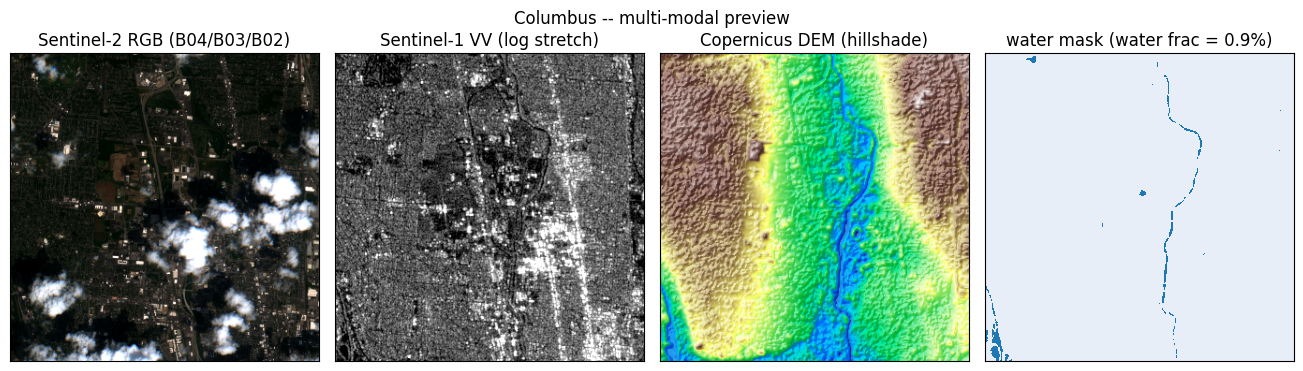

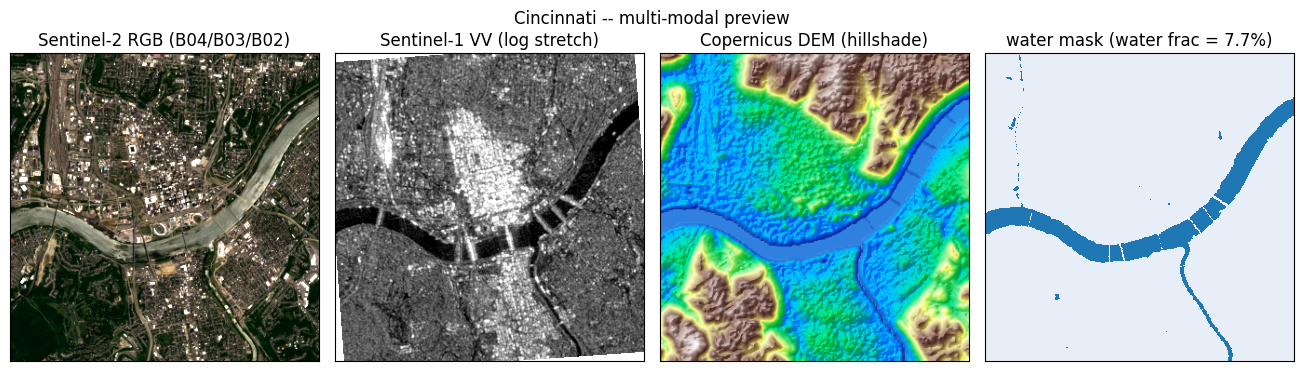

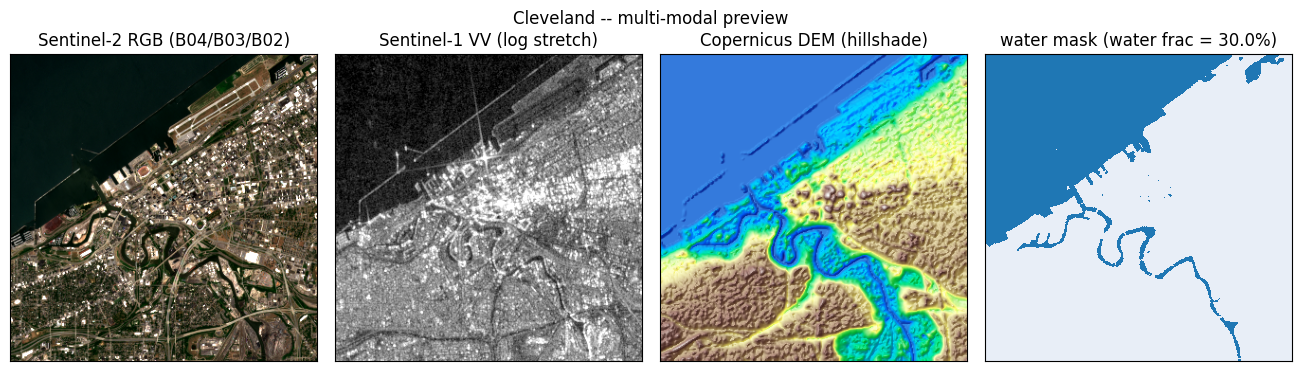

In [9]:
def show_city_panels(city, cube_path):
    """4-panel preview: RGB, S1 VV, DEM hillshade, target-class mask."""
    with rasterio.open(cube_path) as src:
        arr   = src.read()
        descs = list(src.descriptions or [])

    # `find_band` is imported from viz.scenes -- one canonical helper for
    # "give me the channel index of the band ending in this suffix".
    r_i, g_i, b_i = (find_band(descs, "Sentinel-2_B04"),
                    find_band(descs, "Sentinel-2_B03"),
                    find_band(descs, "Sentinel-2_B02"))
    s1_i  = find_band(descs, "Sentinel-1_VV")
    dem_i = find_band(descs, "Copernicus-DEM_DEM")
    lulc_i = find_band(descs, "ESA-WorldCover_LULC")

    fig, axes = plt.subplots(1, 4, figsize=(13, 3.6), constrained_layout=True)
    fig.suptitle(f"{city.title()} -- multi-modal preview", fontsize=12)

    # RGB
    r, g, b = arr[r_i], arr[g_i], arr[b_i]
    rgb = joint_rgb(downsample(r), downsample(g), downsample(b))
    axes[0].imshow(rgb)
    axes[0].set_title("Sentinel-2 RGB (B04/B03/B02)")

    # S1 VV (log)
    s1 = arr[s1_i].astype(np.float32)
    s1 = np.where(s1 > 0, np.log10(s1 + 1e-6), np.nan)
    s1_d = downsample(s1)
    axes[1].imshow(stretch01(s1_d), cmap="gray")
    axes[1].set_title("Sentinel-1 VV (log stretch)")

    # DEM hillshade
    z = arr[dem_i].astype(np.float32)
    z_d = downsample(z)
    ls = LightSource(azdeg=315, altdeg=45)
    shaded = ls.shade(z_d, cmap=plt.cm.terrain, vert_exag=10, blend_mode="soft")
    axes[2].imshow(shaded)
    axes[2].set_title("Copernicus DEM (hillshade)")

    # Target class mask
    lulc = arr[lulc_i]
    mask = (lulc == CLASS_ID).astype(np.float32)
    mask_d = downsample(mask)
    cmap_m = ListedColormap(["#e8eef7", "#1f77b4"])
    axes[3].imshow(mask_d, cmap=cmap_m, vmin=0, vmax=1, interpolation="nearest")
    frac = float(mask.mean())
    axes[3].set_title(f"{CLASS_NAME} mask ({CLASS_NAME} frac = {frac*100:.1f}%)")

    for ax in axes:
        ax.set_xticks([]); ax.set_yticks([])
    plt.show()


for city, cube_path in CITY_CUBES.items():
    show_city_panels(city, cube_path)


Read the four panels per row left to right:

- **RGB** shows the city scene as a human eye would see it. Bare urban
 surfaces (asphalt, concrete) can look as dark as water in shadowed conditions
 -- a classic confound for S2-only water classifiers.
- **S1 VV** is starkly different: water is uniformly dark (low backscatter)
 while urban surfaces are bright (corner reflectors from buildings). Even
 shadowed asphalt is much brighter than open water in SAR.
- **DEM hillshade** tells the topographic story. Rivers carve through valleys;
 Lake Erie is a flat, low plate. Adding elevation as a feature lets the model
 reject high-elevation false positives the optical bands would otherwise miss.
- **Water mask** is the ground truth that we will train against. The mask is
 binary (1 = permanent water from ESA WorldCover class 80, 0 = everything
 else). Cleveland's water fraction is dramatically higher than the other two
 cities, which is exactly the kind of distribution shift we want to test
 generalisation against.


### Spectral indices: NDVI and NDWI

Before we start training anything, a quick **physical sanity check**.
Two normalised-difference indices isolate two of the surfaces we care
most about. They are cheap to compute (just two bands and one division
each, via `compute_ndvi(red, nir)` and `compute_ndwi(green, nir)` from
`geoai_datacubes.preprocessing`) and they reveal a lot about what's in
a scene before any ML.

- **NDVI** = (NIR - Red) / (NIR + Red). High over green vegetation
  because vegetation reflects strongly in NIR but absorbs in red.
- **NDWI** = (Green - NIR) / (Green + NIR). High over open water
  because water absorbs NIR more than it absorbs green.

We render both on the Columbus AOI alongside the true-colour RGB so you
can visually correlate the index maps with what's on the ground.


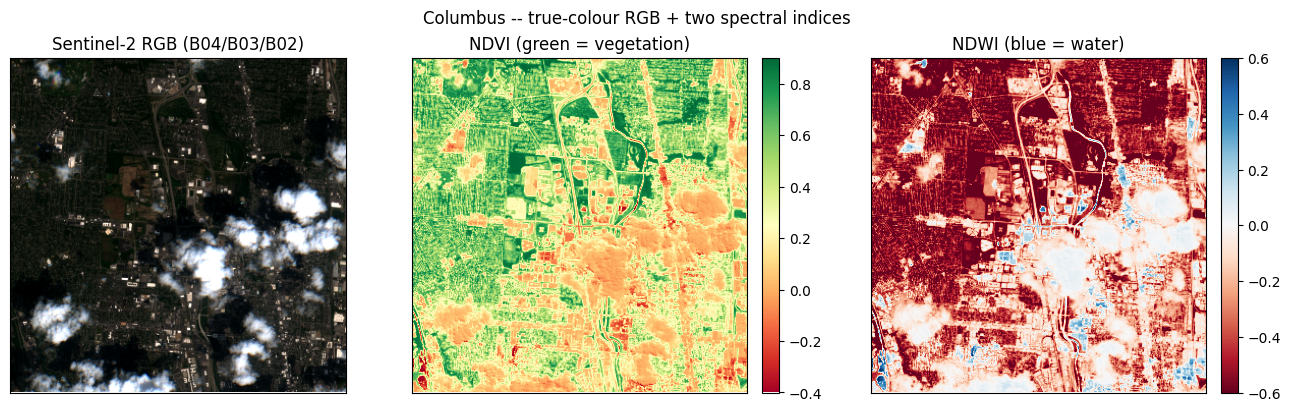


NDVI range : -0.69 .. 0.92
NDWI range : -0.81 .. 0.78


In [10]:
# --- Spectral indices on one city (Columbus) for visual intuition ---
# NDVI / NDWI are computed via the repo helpers; both are scale-invariant
# so we can feed raw DN-units here for visualisation.
with rasterio.open(CITY_CUBES["columbus"]) as src:
    arr   = src.read()
    descs = list(src.descriptions or [])

b2_i = find_band(descs, "Sentinel-2_B02")
b3_i = find_band(descs, "Sentinel-2_B03")
b4_i = find_band(descs, "Sentinel-2_B04")
b8_i = find_band(descs, "Sentinel-2_B08")

blue  = arr[b2_i].astype(np.float32)
green = arr[b3_i].astype(np.float32)
red   = arr[b4_i].astype(np.float32)
nir   = arr[b8_i].astype(np.float32)

ndvi = compute_ndvi(red, nir)
ndwi = compute_ndwi(green, nir)

# Downsample everything by the same step so the three panels share geometry.
red_d   = downsample(red);   green_d = downsample(green); blue_d = downsample(blue)
ndvi_d  = downsample(ndvi);  ndwi_d  = downsample(ndwi)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
fig.suptitle("Columbus -- true-colour RGB + two spectral indices", fontsize=12)

axes[0].imshow(joint_rgb(red_d, green_d, blue_d))
axes[0].set_title("Sentinel-2 RGB (B04/B03/B02)")

im1 = axes[1].imshow(ndvi_d, cmap="RdYlGn", vmin=-0.4, vmax=0.9)
axes[1].set_title("NDVI (green = vegetation)")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(ndwi_d, cmap="RdBu", vmin=-0.6, vmax=0.6)
axes[2].set_title("NDWI (blue = water)")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.show()

print(f"\nNDVI range : {np.nanmin(ndvi):.2f} .. {np.nanmax(ndvi):.2f}")
print(f"NDWI range : {np.nanmin(ndwi):.2f} .. {np.nanmax(ndwi):.2f}")


### DEM preprocessing

The raw DEM band is a poor feature on its own because *absolute* elevation
does not transfer between cities. We handle that in two complementary ways:

- **The DEM channel itself is normalised by the
  `("mean_subtract", 1000.0)` recipe declared on `Copernicus-DEM_DEM` in
  `MISSION_PROFILES`.** `apply_band_norm` (called transparently by
  `harvest_pixels(normalise=True)` and by the U-Net's `BandNormDataset`
  below) subtracts each tile's mean elevation and divides by 1 km. The
  result is a city-relative DEM that encodes "lower than my
  neighbourhood by N km" -- the spatial cue we actually wanted -- and
  transfers cleanly across Columbus (~250 m), Cincinnati (~200 m), and
  Cleveland (~175 m).
- **`DEM_gradient_mag`** -- a separate derived channel computed once on
  the full DEM via `compute_dem_gradient_magnitude(...)` from
  `geoai_datacubes.preprocessing`. Encodes slope without referring to
  absolute elevation. Water surfaces are flat (gradient = 0);
  riverbanks, buildings, and hillsides have non-zero gradient.

The cell below computes the gradient channel **once per city** and
caches it in `CITY_DEM_AUG`. The pixel-harvest helper slices the cached
arrays per tile, so the tree models can see the gradient feature without
re-running anything expensive.


In [11]:
# --- Pre-compute the DEM-gradient feature per city (once) ----------
# Two complementary DEM features land in the cube:
#
#   1. The DEM itself, normalised by the `("mean_subtract", 1000.0)` recipe
#      declared on `Copernicus-DEM_DEM` in MISSION_PROFILES. That recipe is
#      applied transparently by `harvest_pixels(..., normalise=True)` and by
#      the U-Net's `BandNormDataset` below -- so models see "elevation minus
#      the per-tile mean, divided by 1 km" rather than raw metres above sea
#      level. That makes the DEM channel transfer across cities (Columbus
#      sits at ~250 m, Cleveland's Lake Erie shore at ~175 m; absolute
#      elevation would over-fit to one city and predict water everywhere in
#      another).
#
#   2. `DEM_gradient_mag` -- a derived channel computed once on the full DEM
#      via the repo helper `compute_dem_gradient_magnitude(...)`. Encodes
#      slope without referring to absolute elevation: water is flat
#      (gradient = 0), riverbanks, building edges, and hillsides have
#      non-zero gradient. We slice tile windows out of the cached arrays
#      below when harvest_pixels is called.
import zarr

DERIVED_FEATURES = ("DEM_gradient_mag",)
CITY_DEM_AUG = {}    # city -> {"grad_mag", "shape"}

t0 = time.time()
for city, zarr_path in CITY_ZARRS.items():
    z = zarr.open(str(zarr_path), mode="r")
    names = list(z.attrs.get("band_names", []))
    if "Copernicus-DEM_DEM" not in names:
        print(f"{city}: no DEM band, skipping derived features")
        continue
    di = names.index("Copernicus-DEM_DEM")
    dem = np.asarray(z[di, :, :], dtype=np.float32)
    gmag = compute_dem_gradient_magnitude(dem)
    CITY_DEM_AUG[city] = {"grad_mag": gmag, "shape": dem.shape}
    finite = np.isfinite(gmag)
    p99 = float(np.percentile(gmag[finite], 99)) if finite.any() else float("nan")
    print(f"{city:>11s}: DEM_gradient_mag p99={p99:.2f} m/px")
print(f"DEM augmentation computed in {time.time()-t0:.1f}s")


   columbus: DEM_gradient_mag p99=2.21 m/px
 cincinnati: DEM_gradient_mag p99=4.67 m/px
  cleveland: DEM_gradient_mag p99=2.68 m/px
DEM augmentation computed in 0.1s


## 7. ML: Pixel-level classifiers (Logistic Regression, Random Forest, XGBoost)

The simplest ML setup for water classification is **per-pixel** classification:
each pixel is one training example with one feature vector (the six S2 + S1
band values plus the derived DEM gradient channel) and one binary label
(water? yes/no). We harvest those vectors via
`geoai_datacubes.ml_dl.harvest_pixels`, which walks a `LazyTileDataset`
internally, applies the per-band `band_meta` normalisation recipes, and
concatenates any pre-computed `derived_arrays` at the same tile window.

We use **all three classifiers** at this stage so you can compare their
behaviour on identical inputs:

- **Logistic Regression** -- the linear baseline. Cheap, interpretable, good
  reference for "what's the easy signal here?".
- **Random Forest** (sklearn) -- non-linear with feature interactions, robust
  to scale, no preprocessing needed.
- **XGBoost** -- gradient-boosted trees, usually the strongest tabular model.

The three cities are mixed at every split (train / val / test). That mirrors
real deployment, where models are trained on a regional union of geographies
rather than a single city. The `S2-only` -> `S2+S1` -> `S2+S1+DEM` ablation in
section 8 then breaks the per-mission contribution out for the same models.


In [12]:
# --- Harvest pixel-level (X, y) per (city, split) ------------------
# Uses the repo helper `geoai_datacubes.ml_dl.harvest_pixels`, which:
#   * walks a LazyTileDataset for the requested split,
#   * applies `apply_band_norm` per band using each band's `band_meta`
#     recipe (S2 spectral -> linear/10000, S1 SAR -> log_db,
#     DEM elevation -> mean_subtract/1000 m, ...), so every model sees
#     features on a comparable [0, 1]-ish scale,
#   * optionally concatenates pre-computed `derived_arrays` (here:
#     DEM_gradient_mag from the previous cell) at the matching tile
#     window.
# The same helper is called by `benchmark_lulc_class.py` (CLI), so the
# notebook and the per-class sweep cannot drift apart.

PIXEL_FEATURES = [
    "Sentinel-2_B02", "Sentinel-2_B03", "Sentinel-2_B04", "Sentinel-2_B08",
    "Sentinel-1_VV",  "Sentinel-1_VH",
]
LABEL_BAND = "ESA-WorldCover_LULC"
CITIES = ["columbus", "cincinnati", "cleveland"]
SPLIT_RATIOS = (0.70, 0.15, 0.15)


t0 = time.time()
PIXEL_DATA = {}     # (city, split) -> (X, y)
print(f"{'city':<11s} {'split':<5s}  {'pixels':>12s}  {CLASS_NAME:>10s}")
for city in CITIES:
    derived = ({"DEM_gradient_mag": CITY_DEM_AUG[city]["grad_mag"]}
               if city in CITY_DEM_AUG else None)
    for split in ("train", "val", "test"):
        s0 = time.time()
        X, y = harvest_pixels(
            CITY_ZARRS[city], split=split,
            feature_bands=PIXEL_FEATURES,
            label_band=LABEL_BAND,
            label_remap={CLASS_ID: 1},
            split_ratios=SPLIT_RATIOS,
            split_method="random",
            tile_size=64, stride=64,
            derived_arrays=derived,
            normalise=True,
            seed=SEED,
        )
        n_pos = int(y.sum()); n_total = int(y.size)
        PIXEL_DATA[(city, split)] = (X, y)
        print(f"{city:<9s} {split:<5s}  {n_total:>12,d}  "
              f"{n_pos:>8,d} ({100*n_pos/max(1,n_total):4.1f}%)  "
              f"[{time.time()-s0:.1f}s]")
print(f"Total harvest time: {time.time()-t0:.1f}s")


city        split        pixels       water
columbus  train       286,720     2,685 ( 0.9%)  [0.1s]
columbus  val          69,632       375 ( 0.5%)  [0.0s]
columbus  test         53,248       405 ( 0.8%)  [0.0s]


cincinnati train       266,240    24,084 ( 9.0%)  [0.1s]
cincinnati val          61,440     4,400 ( 7.2%)  [0.0s]
cincinnati test         45,056     4,068 ( 9.0%)  [0.0s]
cleveland train       286,720    89,333 (31.2%)  [0.1s]
cleveland val          69,632    14,512 (20.8%)  [0.0s]
cleveland test         53,248    22,864 (42.9%)  [0.0s]
Total harvest time: 0.4s


Mix all three cities into a single training set. Validation and test pixels are kept at their **natural class distributions** so the reported metrics reflect real-world deployment, but training is **balanced 1:5 (water:land)** so the models are not tempted to just predict “land everywhere” to satisfy ~99% accuracy.


In [13]:
t0 = time.time()
# --- Mix cities at every split; balance only the TRAINING set ---
# We intentionally leave val and test unbalanced (their natural class
# distribution) so reported metrics reflect real-world deployment, not a
# cherry-picked subsample. Training is balanced 1:5 (target:rest) so models
# do not just predict "rest everywhere" to satisfy 99% accuracy.
# `balance_pos_neg` is imported from geoai_datacubes.ml_dl -- the same
# helper used by `benchmark_lulc_class.py`.

def concat_cities(split, balance=False):
    Xs, ys = [], []
    n_feat = len(PIXEL_FEATURES) + len(DERIVED_FEATURES)
    for city in CITIES:
        X, y = PIXEL_DATA[(city, split)]
        if len(X):
            Xs.append(X); ys.append(y)
    X = np.concatenate(Xs) if Xs else np.empty((0, n_feat))
    y = np.concatenate(ys) if ys else np.empty((0,), dtype=np.int64)
    if balance and len(y):
        X, y = balance_pos_neg(X, y, max_ratio=5, seed=SEED)
    return X, y


X_train, y_train = concat_cities("train", balance=True)
X_val,   y_val   = concat_cities("val",   balance=False)
X_test,  y_test  = concat_cities("test",  balance=False)

def _line(name, X, y):
    n_pos = int(y.sum()); n_total = int(y.size)
    print(f"{name:<13s}  pixels={n_total:>9,d}  {CLASS_NAME}={n_pos:>7,d}  "
          f"({100*n_pos/max(1,n_total):4.1f}%)")
print("Mixed across all three cities:")
_line("train (1:5)", X_train, y_train)
_line("val (raw)",   X_val,   y_val)
_line("test (raw)",  X_test,  y_test)

print(f"\nMix + balance done in {time.time()-t0:.1f}s")


Mixed across all three cities:
train (1:5)    pixels=  696,612  water=116,102  (16.7%)
val (raw)      pixels=  200,704  water= 19,287  ( 9.6%)
test (raw)     pixels=  151,552  water= 27,337  (18.0%)

Mix + balance done in 0.1s


### What “threshold tuning” means

Most classifiers do not output a binary “water or not” directly. They output a **continuous score** in [0, 1] — a probability or pseudo-probability. To turn that into a binary prediction we apply a **decision threshold** τ:

- score ≥ τ → predict **water**
- score < τ → predict **land**

The default is τ = 0.5 (“more likely than not”), but for an imbalanced binary problem like ours (water is only ~5% of pixels averaged across the cities) τ = 0.5 is rarely optimal. A model that *ranks* pixels well — water pixels generally getting higher scores than land pixels — might still have a poor F1 at τ = 0.5 because the precision is dragged down by the small wedge of false positives just above 0.5.

We tune τ on the **validation set** by sweeping a range of thresholds and picking the one that maximises F1, then **lock that τ in** and report the metrics on the (held-out) test set. This is why our LogReg model reaches F1 ≈ 0.90 even though its default-threshold F1 would be much lower.


In [14]:
# --- Train three classifiers on the mixed-city training set ---
# Features arrive already on a comparable [0, 1]-ish scale because
# `harvest_pixels(..., normalise=True)` applied each band's `band_meta`
# recipe (linear for S2 spectral, log_db for S1 SAR, mean_subtract for
# DEM). LR therefore no longer needs a `StandardScaler` step; the
# classifier sees pre-normalised features directly. RF and XGB are
# scale-invariant either way.
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble     import RandomForestClassifier
import xgboost as xgb
from threadpoolctl import threadpool_limits
import joblib

# scale_pos_weight for XGBoost (negatives / positives after balancing)
n_pos = int(y_train.sum())
n_neg = int((y_train == 0).sum())
spw = max(1.0, n_neg / max(1, n_pos))

# Cache paths -- keyed on the target class id so a CLASS_ID switch
# invalidates the cache automatically.
RF_CACHE  = MODEL_CACHE_DIR / f"rf_class{CLASS_ID}.joblib"
XGB_CACHE = MODEL_CACHE_DIR / f"xgb_class{CLASS_ID}.joblib"

# Cap all C-extension thread pools to 1 for the duration of training.
# The macOS + Anaconda env has two OpenBLAS instances (numpy + scipy)
# plus libomp competing for cores, and xgboost is liable to segfault
# during fit() under that load. threadpoolctl is the same workaround
# the KMeans cell uses later.
with threadpool_limits(limits=1):
    # LR is fast (~1 s) so we always retrain -- no cache. No StandardScaler
    # in front: features are pre-normalised by apply_band_norm at harvest.
    t0 = time.time()
    lr_clf = LogisticRegression(max_iter=2000,
                                class_weight="balanced",
                                random_state=SEED)
    lr_clf.fit(X_train, y_train)
    print(f"LR  trained in {time.time()-t0:.1f}s")

    # RF -- the slow one. Cache hit is a 9-min savings on macOS.
    if USE_CACHED_MODELS and RF_CACHE.exists():
        t0 = time.time()
        rf_clf = joblib.load(RF_CACHE)
        print(f"RF  loaded from cache {RF_CACHE.name} in {time.time()-t0:.1f}s")
    else:
        t0 = time.time()
        rf_clf = RandomForestClassifier(n_estimators=200, max_depth=14,
                                        n_jobs=1, class_weight="balanced",
                                        random_state=SEED)
        rf_clf.fit(X_train, y_train)
        train_sec = time.time() - t0
        joblib.dump(rf_clf, RF_CACHE, compress=3)
        size_mb = RF_CACHE.stat().st_size / 1024 / 1024
        print(f"RF  trained in {train_sec:.1f}s -> saved {RF_CACHE.name} ({size_mb:.1f} MB)")

    # XGB -- cache for symmetry (~8s saved per run).
    if USE_CACHED_MODELS and XGB_CACHE.exists():
        t0 = time.time()
        xgb_clf = joblib.load(XGB_CACHE)
        print(f"XGB loaded from cache {XGB_CACHE.name} in {time.time()-t0:.1f}s")
    else:
        t0 = time.time()
        xgb_clf = xgb.XGBClassifier(n_estimators=300, max_depth=6,
                                    learning_rate=0.1,
                                    tree_method="hist", eval_metric="logloss",
                                    scale_pos_weight=spw,
                                    random_state=SEED, n_jobs=1)
        xgb_clf.fit(X_train, y_train)
        train_sec = time.time() - t0
        joblib.dump(xgb_clf, XGB_CACHE, compress=3)
        size_mb = XGB_CACHE.stat().st_size / 1024 / 1024
        print(f"XGB trained in {train_sec:.1f}s -> saved {XGB_CACHE.name} ({size_mb:.1f} MB)")

MODELS = {"LogReg": lr_clf, "RF": rf_clf, "XGB": xgb_clf}

# `tune_threshold` is imported from geoai_datacubes.ml_dl -- same code
# path as `benchmark_lulc_class.py` and `benchmark_unet_class.py`.
THRESHOLDS = {}
print("\nThresholds tuned on val (F1-optimal):")
for name, model in MODELS.items():
    THRESHOLDS[name] = tune_threshold(model, X_val, y_val)
    print(f"{name:>6s}  thr={THRESHOLDS[name]:.3f}")


LR  trained in 1.6s


RF  loaded from cache rf_class80.joblib in 0.4s
XGB loaded from cache xgb_class80.joblib in 0.0s

Thresholds tuned on val (F1-optimal):
LogReg  thr=0.845


    RF  thr=0.533


   XGB  thr=0.808


### Reading the binary classification metrics

<details>
<summary><b>Click to expand: what TP / FP / FN / TN / precision / recall / F1 / IoU / AUC actually mean</b></summary>

After we apply a threshold, every pixel falls into one of four cells of the **confusion matrix**:

| | predicted **water** | predicted **land** |
|---|---|---|
| **truly water** | TP (true positive) | FN (false negative) |
| **truly land** | FP (false positive) | TN (true negative) |

From these counts we compute:

- **Precision** = TP / (TP + FP) — *“of the pixels I called water, how many really are water?”* High precision means few false alarms.
- **Recall (sensitivity)** = TP / (TP + FN) — *“of all the water pixels in the scene, how many did I find?”* High recall means few missed detections.
- **F1** = 2·P·R / (P + R) — harmonic mean of precision and recall. A single number that is high *only* when both are high. This is the headline metric for imbalanced binary problems.
- **IoU (intersection over union)** = TP / (TP + FP + FN) — the strict version of F1, used as the standard segmentation metric in computer vision. IoU is always a bit lower than F1.
- **Accuracy** = (TP + TN) / N — *“what fraction of pixels did I get right?”* Misleading for imbalanced classes: a model that predicts “land” everywhere would still score 95%+ accuracy in our setup.
- **AUC (area under the ROC curve)** — measures the *ranking* quality of the model **independent** of any specific threshold. AUC = 0.99 means the model nearly always assigns a higher score to water pixels than to land pixels, even if the default τ = 0.5 happens to be wrong. A weak ranker (AUC near 0.5) cannot be saved by threshold tuning; a strong ranker (AUC near 1.0) can.

The next cell prints all of these per model and per evaluation scope, then the cell after that plots the confusion matrices.

</details>


In [15]:
# --- Evaluate with the tuned threshold on val and on test ---
# Per-city breakdown lets us see whether the model does equally well in all
# three cities or whether one geography dominates the aggregate numbers.
# `binary_pixel_metrics` and `predict_with_threshold` are imported from
# geoai_datacubes.ml_dl.

rows = []
EVAL_CACHE = {}      # (name, scope) -> (y, pred, prob)
_eval_rng = np.random.default_rng(SEED)
for name, model in MODELS.items():
    thr = THRESHOLDS[name]
    for scope_name, scope_split in [("test (mixed)", "test"),
                                     ("val (mixed)",  "val")]:
        X = X_test if scope_split == "test" else X_val
        y = y_test if scope_split == "test" else y_val
        pred = predict_with_threshold(model, X, thr)
        prob = model.predict_proba(X)[:, 1]
        rows.append({"model": name, "scope": scope_name,
                     **binary_pixel_metrics(y, pred, prob)})
        EVAL_CACHE[(name, scope_split)] = (y, pred, prob)
    # Also per-city test for the breakdown.
    for city in CITIES:
        X, y = PIXEL_DATA[(city, "test")]
        if len(X) == 0:
            continue
        # Cap eval size for very large test sets (Cleveland).
        if len(X) > 200_000:
            idx = _eval_rng.choice(len(X), 200_000, replace=False)
            X, y = X[idx], y[idx]
        pred = predict_with_threshold(model, X, thr)
        prob = model.predict_proba(X)[:, 1]
        rows.append({"model": name, "scope": f"test ({city})",
                     **binary_pixel_metrics(y, pred, prob)})
        EVAL_CACHE[(name, f"test_{city}")] = (y, pred, prob)

metrics_df = pd.DataFrame(rows)
# Rename the legacy `n_pos` column header to remain readable when the
# CLASS_ID is something other than water.
metrics_df = metrics_df.rename(columns={"n_pos": f"n_{CLASS_NAME}_true"})
ordered_cols = ["model", "scope", "n", f"n_{CLASS_NAME}_true",
                "acc", "prec", "rec", "f1", "iou", "auc"]
metrics_df = metrics_df[ordered_cols]
print(metrics_df.to_string(index=False,
                            float_format=lambda x: f"{x:.3f}",
                            formatters={"n": "{:>10,d}".format,
                                        f"n_{CLASS_NAME}_true": "{:>8,d}".format}))


 model             scope          n n_water_true   acc  prec   rec    f1   iou   auc
LogReg      test (mixed)    151,552       27,337 0.972 0.975 0.869 0.919 0.850 0.977
LogReg       val (mixed)    200,704       19,287 0.980 0.959 0.824 0.886 0.796 0.973
LogReg   test (columbus)     53,248          405 0.989 0.380 0.679 0.488 0.322 0.965
LogReg test (cincinnati)     45,056        4,068 0.986 0.983 0.865 0.920 0.852 0.989
LogReg  test (cleveland)     53,248       22,864 0.944 0.995 0.873 0.930 0.869 0.973
    RF      test (mixed)    151,552       27,337 0.980 0.974 0.912 0.942 0.890 0.984
    RF       val (mixed)    200,704       19,287 0.986 0.966 0.884 0.923 0.857 0.985
    RF   test (columbus)     53,248          405 0.989 0.371 0.578 0.452 0.292 0.969
    RF test (cincinnati)     45,056        4,068 0.991 0.978 0.920 0.948 0.901 0.995
    RF  test (cleveland)     53,248       22,864 0.960 0.991 0.916 0.952 0.909 0.980
   XGB      test (mixed)    151,552       27,337 0.982 0.978 0.91

Confusion matrices for each (model, scope) pair. Columns are evaluation scopes (mixed test + per-city breakdown); rows are the three pixel-level classifiers. Each matrix is row-normalised so the diagonal cells read as class-conditional accuracy (proportion of water pixels predicted as water, proportion of land pixels predicted as land). A perfect classifier would show 1.00 on the diagonals and 0.00 off-diagonal.


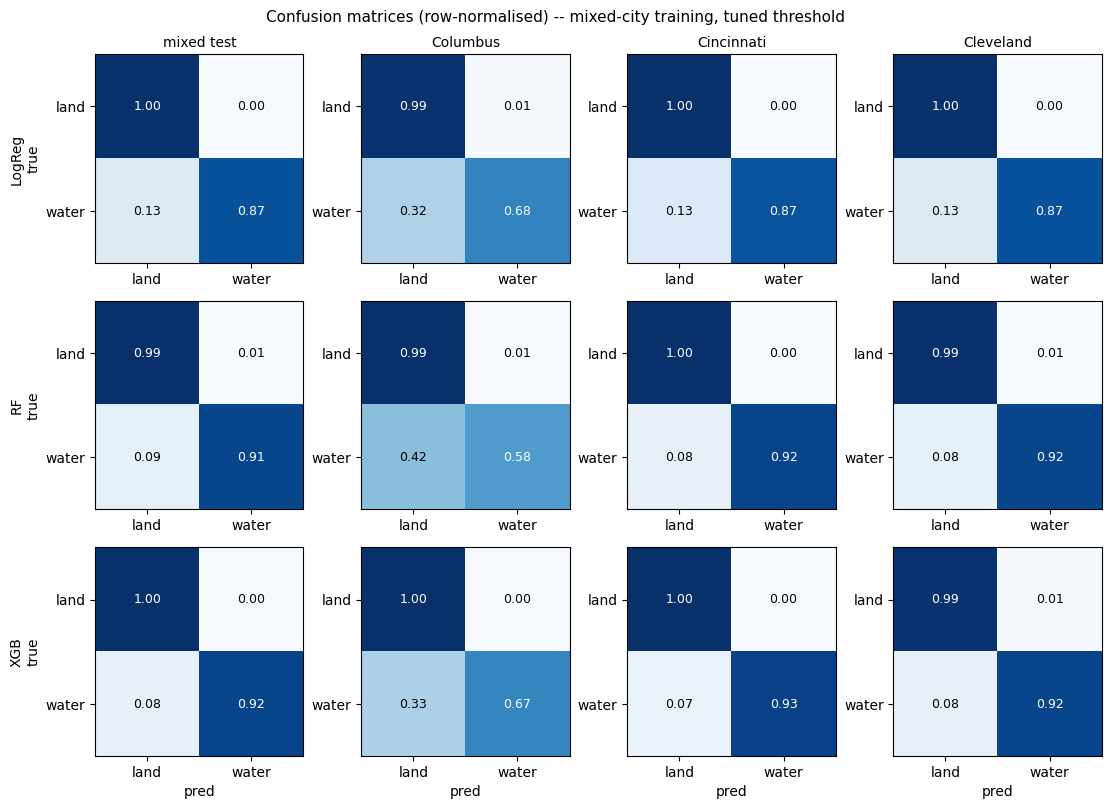

In [16]:
# --- Confusion matrices (row-normalised): 3 models x 4 evaluation scopes ---
# Columns are: mixed test (the headline) + per-city test breakdown.
scopes = ["test", "test_columbus", "test_cincinnati", "test_cleveland"]
scope_titles = ["mixed test", "Columbus", "Cincinnati", "Cleveland"]
n_cols = len(scopes)
n_rows = len(MODELS)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(11, 8), constrained_layout=True)
for i, (model_name, model) in enumerate(MODELS.items()):
    for j, scope in enumerate(scopes):
        ax = axes[i, j]
        if (model_name, scope) not in EVAL_CACHE:
            ax.axis("off"); continue
        y_true, y_pred, _ = EVAL_CACHE[(model_name, scope)]
        from sklearn.metrics import confusion_matrix
        cm = confusion_matrix(y_true, y_pred, normalize="true")
        ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
        for r in range(2):
            for c in range(2):
                ax.text(c, r, f"{cm[r,c]:.2f}",
                        ha="center", va="center",
                        color="white" if cm[r,c] > 0.5 else "black",
                        fontsize=9)
        ax.set_xticks([0, 1], ["land", "water"])
        ax.set_yticks([0, 1], ["land", "water"])
        if i == 0:
            ax.set_title(scope_titles[j], fontsize=10)
        if j == 0:
            ax.set_ylabel(f"{model_name}\ntrue", fontsize=10)
        if i == n_rows - 1:
            ax.set_xlabel("pred")
fig.suptitle("Confusion matrices (row-normalised) -- mixed-city training, tuned threshold",
             fontsize=11)
plt.show()


Tree-based models naturally expose **feature importance** — which input bands the model relied on. For water classification we'd expect Sentinel-1 VV (specular reflection from water = near-zero backscatter), Sentinel-2 B08 (NIR is absorbed by water and bright over vegetation), and the DEM-derived features to rank high. The bars below confirm that intuition.


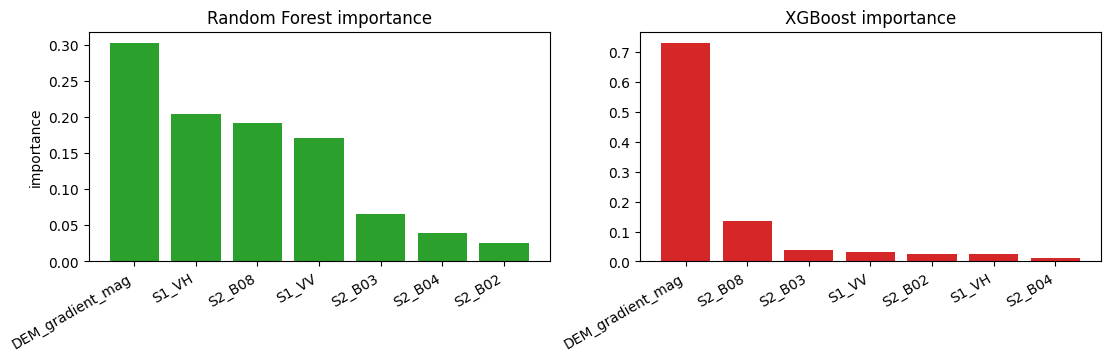

In [17]:
# --- Feature importance for tree models ---
# `rf_clf` and `xgb_clf` were trained on PIXEL_FEATURES + DERIVED_FEATURES
# (the S2/S1 bands plus the DEM_gradient_mag channel), so the importance
# vector has len(PIXEL_FEATURES) + len(DERIVED_FEATURES) entries. We
# render labels matching that combined list.
ALL_FEATURE_NAMES = list(PIXEL_FEATURES) + list(DERIVED_FEATURES)
short_names = [f.replace("Sentinel-2_", "S2_")
                .replace("Sentinel-1_", "S1_")
                .replace("Copernicus-DEM_", "")
              for f in ALL_FEATURE_NAMES]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), constrained_layout=True)

order_rf = np.argsort(rf_clf.feature_importances_)[::-1]
axes[0].bar(range(len(ALL_FEATURE_NAMES)),
            rf_clf.feature_importances_[order_rf], color="#2ca02c")
axes[0].set_xticks(range(len(ALL_FEATURE_NAMES)))
axes[0].set_xticklabels([short_names[i] for i in order_rf], rotation=30, ha="right")
axes[0].set_title("Random Forest importance"); axes[0].set_ylabel("importance")

order_x = np.argsort(xgb_clf.feature_importances_)[::-1]
axes[1].bar(range(len(ALL_FEATURE_NAMES)),
            xgb_clf.feature_importances_[order_x], color="#d62728")
axes[1].set_xticks(range(len(ALL_FEATURE_NAMES)))
axes[1].set_xticklabels([short_names[i] for i in order_x], rotation=30, ha="right")
axes[1].set_title("XGBoost importance")
plt.show()


**ROC curves** plot the false-positive rate against the true-positive rate as the decision threshold sweeps from 0 to 1. The area under the curve (AUC) is the threshold-independent ranking quality of the model. The closer the curve hugs the top-left corner, the better the model is at ranking water pixels above land pixels independent of where you draw the τ line.


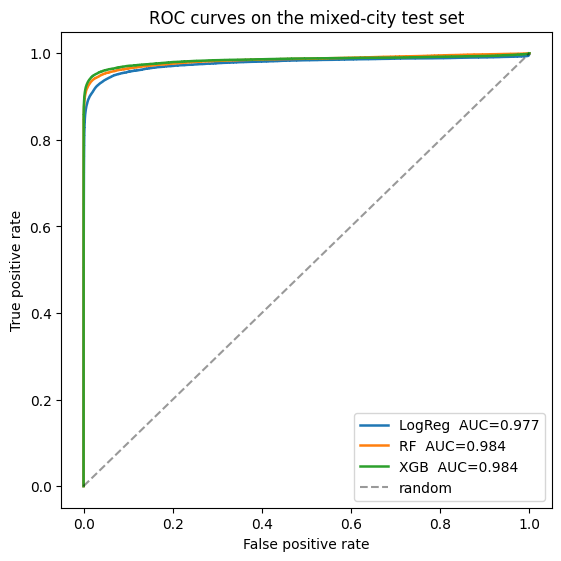

In [18]:
# --- ROC curves on the mixed test set ---
from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(5.5, 5.5), constrained_layout=True)
for model_name in MODELS.keys():
    y_true, _, y_prob = EVAL_CACHE[(model_name, "test")]
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    try:    auc = roc_auc_score(y_true, y_prob)
    except: auc = float("nan")
    ax.plot(fpr, tpr, label=f"{model_name}  AUC={auc:.3f}", linewidth=1.8)
ax.plot([0,1], [0,1], "k--", alpha=0.4, label="random")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("ROC curves on the mixed-city test set")
ax.legend(loc="lower right")
plt.show()


### Sanity-check baseline: a thresholded spectral index

The simplest possible "model" is a single threshold on the right
spectral index. For water we use **NDWI** (Green - NIR) / (Green + NIR);
for vegetation classes (tree cover, grassland, cropland) we use **NDVI**
(NIR - Red) / (NIR + Red). Other classes have no simple index baseline
in this notebook -- NDBI for built-up would need SWIR1, which we do not
fetch.

The threshold is **tuned on validation** to maximise F1, then applied
to the test set unchanged. Comparing the trained models against this
baseline tells you whether the ML models are actually learning
something *beyond* "high index value = positive".


In [19]:
# --- Baseline: threshold a physical spectral index ---
# The features are already normalised (S2 spectral via the ``linear``
# recipe). Both NDWI = (G - N)/(G + N) and NDVI = (N - R)/(N + R) are
# scale-invariant, so we can compute them directly on the normalised
# features without rescaling first. We use the repo helpers
# `compute_ndvi` / `compute_ndwi` from preprocessing.band_ops for the
# 2D path; for these tabular columns the math is one liner.
from sklearn.metrics import f1_score


def ndwi_from_pixels(X, band_order):
    g = X[:, band_order.index("Sentinel-2_B03")]
    n = X[:, band_order.index("Sentinel-2_B08")]
    return compute_ndwi(g, n)


def ndvi_from_pixels(X, band_order):
    r = X[:, band_order.index("Sentinel-2_B04")]
    n = X[:, band_order.index("Sentinel-2_B08")]
    return compute_ndvi(r, n)


# Pick the right index for the chosen target class.
BASELINE_INDEX = None
if CLASS_ID == 80:
    BASELINE_INDEX = ("NDWI", ndwi_from_pixels)
elif CLASS_ID in (10, 30, 40):
    BASELINE_INDEX = ("NDVI", ndvi_from_pixels)

if BASELINE_INDEX is None:
    print(f"No simple spectral-index baseline configured for CLASS_ID={CLASS_ID}.")
    print("Skipping the baseline cell -- the four-model comparison below still runs.")
    m_baseline = None
else:
    idx_name, idx_fn = BASELINE_INDEX
    t0 = time.time()
    bl_val  = idx_fn(X_val,  PIXEL_FEATURES)
    bl_test = idx_fn(X_test, PIXEL_FEATURES)
    # Sweep thresholds on val, pick the one maximising F1. Both NDWI and
    # NDVI sit on [-1, 1]; sweep wide enough.
    sweep = np.linspace(-0.5, 0.8, 131)
    best_f1, best_thr = -1.0, 0.0
    for thr in sweep:
        pred = (bl_val > thr).astype(np.int64)
        f1 = f1_score(y_val, pred, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr

    bl_pred_test = (bl_test > best_thr).astype(np.int64)
    m_baseline = binary_pixel_metrics(y_test, bl_pred_test, bl_test)
    print(f"{idx_name} baseline (threshold tuned on val):")
    print(f"best threshold: {best_thr:.3f}  (val F1 = {best_f1:.3f})")
    print(f"test F1 = {m_baseline['f1']:.3f}  prec = {m_baseline['prec']:.3f}  "
          f"rec = {m_baseline['rec']:.3f}  AUC = {m_baseline['auc']:.3f}  "
          f"({time.time()-t0:.1f}s)")


NDWI baseline (threshold tuned on val):
best threshold: 0.030  (val F1 = 0.853)
test F1 = 0.925  prec = 0.953  rec = 0.899  AUC = 0.967  (5.1s)


**Reading the diagnostics:**

- **Confusion matrices** are row-normalised, so each row sums to 1. The
 diagonal cells show how often the model gets the class right. Off-diagonal
 cells show the two error modes: false-positives (top-right = land predicted
 as water) and false-negatives (bottom-left = water predicted as land). For
 water mapping the top-right cell is usually the dangerous one.
- **Feature importance**: in a healthy water classifier you should see the SAR
 bands (`S1_VV`, `S1_VH`) and NIR (`S2_B08`) at the top, plus DEM somewhere
 in the mix. SAR carries most of the discriminative signal because water is a
 near-perfect specular reflector.
- **ROC curves** sweep the decision threshold and trace true-positive vs
 false-positive rate. Curves closer to the upper-left corner are stronger
 classifiers. AUC = 1.0 is perfect, 0.5 is random.


## 8. Does adding modalities help? Within-context vs across-context

We train a Random Forest with three feature sets -- S2 alone, S2+S1, S2+S1+DEM
-- and evaluate the same model under two different deployment scenarios:

1. **Within-context (mixed-city)**: train and test pixels are drawn from all
 three cities. This is the realistic deployment story: you have access to
 labels at every place you want to predict.
2. **Cross-context (Columbus-only train)**: train on Columbus pixels alone,
 test on Cleveland alone. This is the cold-start "train it once and ship
 it" story.

Watch what happens to DEM in the two scenarios. Domain experts use water masks
as *inputs* to DEM construction in the first place (water surfaces are awful
for stereo / lidar matching), so it should not be surprising if a DEM band
turns out to be a noisy proxy for water at best -- and a hard distribution-
shift trap at worst when the elevation prior does not transfer between cities.


In [20]:
# Three feature sets, three context settings:
#   S2 alone, S2+S1, and S2+S1 plus our derived DEM features.
# Two scopes:
#   1. mixed-city: train and test pixels drawn from all three cities
#   2. cross-city: Columbus train -> Cleveland test (worst-case shift)
# The DEM-with-band-meta + DEM_gradient_mag combination transfers across
# cities because the recipe strips away the absolute-elevation prior.

FEATURE_SETS = {
    "S2"        : ["Sentinel-2_B02", "Sentinel-2_B03", "Sentinel-2_B04", "Sentinel-2_B08"],
    "S2+S1"     : ["Sentinel-2_B02", "Sentinel-2_B03", "Sentinel-2_B04", "Sentinel-2_B08",
                   "Sentinel-1_VV",  "Sentinel-1_VH"],
    "S2+S1+DEM" : ["Sentinel-2_B02", "Sentinel-2_B03", "Sentinel-2_B04", "Sentinel-2_B08",
                   "Sentinel-1_VV",  "Sentinel-1_VH",
                   "Copernicus-DEM_DEM"],   # mean_subtract recipe applied automatically
}
# DEM_gradient_mag is fed as a `derived_arrays={...}` channel so the
# helper doesn't need a Zarr band for it.

# Cache the final fusion_df so a re-run can skip the 6 x RF retrain loop.
FUSION_CACHE = MODEL_CACHE_DIR / f"fusion_df_class{CLASS_ID}.json"

if USE_CACHED_MODELS and FUSION_CACHE.exists():
    t0 = time.time()
    fusion_df = pd.read_json(FUSION_CACHE, orient="records")
    mixed_df = fusion_df[fusion_df["scope"] == "mixed"].reset_index(drop=True)
    cross_df = fusion_df[fusion_df["scope"] == "cross-city"].reset_index(drop=True)
    print(f"Fusion comparison loaded from cache {FUSION_CACHE.name} "
          f"in {time.time()-t0:.1f}s")
    print(fusion_df[["scope","set","n_bands","prec","rec","f1","iou","auc","secs"]]
           .to_string(index=False, float_format=lambda x: f"{x:.3f}"))
else:
    def _harvest(zarr_path, split, bands, *, derived=None):
        return harvest_pixels(
            zarr_path, split=split,
            feature_bands=bands,
            label_band=LABEL_BAND,
            label_remap={CLASS_ID: 1},
            split_ratios=SPLIT_RATIOS,
            split_method="random",
            tile_size=64, stride=64,
            derived_arrays=derived,
            normalise=True,
            seed=SEED,
        )

    def harvest_mixed_split(split, bands, want_gradient):
        Xs, ys = [], []
        for city in CITIES:
            derived = ({"DEM_gradient_mag": CITY_DEM_AUG[city]["grad_mag"]}
                       if want_gradient and city in CITY_DEM_AUG else None)
            X, y = _harvest(CITY_ZARRS[city], split, bands, derived=derived)
            if len(X):
                Xs.append(X); ys.append(y)
        if not Xs:
            return (np.empty((0, len(bands) + (1 if want_gradient else 0))),
                    np.empty((0,), dtype=np.int64))
        return np.concatenate(Xs), np.concatenate(ys)

    def fit_rf_threshold_eval(X_tr, y_tr, X_va, y_va, X_te, y_te):
        X_tr, y_tr = balance_pos_neg(X_tr, y_tr, max_ratio=5, seed=SEED)
        with threadpool_limits(limits=1):
            rf = RandomForestClassifier(n_estimators=200, max_depth=14, n_jobs=1,
                                        class_weight="balanced", random_state=SEED)
            rf.fit(X_tr, y_tr)
        thr  = tune_threshold(rf, X_va, y_va) if y_va.sum() else 0.5
        prob = rf.predict_proba(X_te)[:, 1]
        pred = (prob >= thr).astype(np.int64)
        return binary_pixel_metrics(y_te, pred, prob)

    mixed_rows, cross_rows = [], []
    t_all = time.time()
    for set_name, bands in FEATURE_SETS.items():
        want_grad = (set_name == "S2+S1+DEM")
        t0 = time.time()
        X_tr, y_tr = harvest_mixed_split("train", bands, want_grad)
        X_va, y_va = harvest_mixed_split("val",   bands, want_grad)
        X_te, y_te = harvest_mixed_split("test",  bands, want_grad)
        m = fit_rf_threshold_eval(X_tr, y_tr, X_va, y_va, X_te, y_te)
        n_bands_eff = len(bands) + (1 if want_grad else 0)
        mixed_rows.append({"set": set_name, "n_bands": n_bands_eff, **m,
                           "secs": time.time()-t0})
        print(f"mixed      {set_name:>12s}  ({n_bands_eff} bands)  F1={m['f1']:.3f}  "
              f"[{time.time()-t0:.1f}s]")

    for set_name, bands in FEATURE_SETS.items():
        want_grad = (set_name == "S2+S1+DEM")
        t0 = time.time()
        derived_cols = ({"DEM_gradient_mag": CITY_DEM_AUG["columbus"]["grad_mag"]}
                        if want_grad and "columbus" in CITY_DEM_AUG else None)
        derived_cinc = ({"DEM_gradient_mag": CITY_DEM_AUG["cincinnati"]["grad_mag"]}
                        if want_grad and "cincinnati" in CITY_DEM_AUG else None)
        derived_clev = ({"DEM_gradient_mag": CITY_DEM_AUG["cleveland"]["grad_mag"]}
                        if want_grad and "cleveland" in CITY_DEM_AUG else None)
        X_tr, y_tr = _harvest(CITY_ZARRS["columbus"],   "train", bands, derived=derived_cols)
        X_va, y_va = _harvest(CITY_ZARRS["cincinnati"], "val",   bands, derived=derived_cinc)
        X_te, y_te = _harvest(CITY_ZARRS["cleveland"],  "test",  bands, derived=derived_clev)
        m = fit_rf_threshold_eval(X_tr, y_tr, X_va, y_va, X_te, y_te)
        n_bands_eff = len(bands) + (1 if want_grad else 0)
        cross_rows.append({"set": set_name, "n_bands": n_bands_eff, **m,
                           "secs": time.time()-t0})
        print(f"cross-city {set_name:>12s}  ({n_bands_eff} bands)  F1={m['f1']:.3f}  "
              f"[{time.time()-t0:.1f}s]")

    mixed_df = pd.DataFrame(mixed_rows).assign(scope="mixed")
    cross_df = pd.DataFrame(cross_rows).assign(scope="cross-city")
    fusion_df = pd.concat([mixed_df, cross_df], ignore_index=True)
    print(f"\nFusion comparison done in {time.time()-t_all:.1f}s")
    print(fusion_df[["scope","set","n_bands","prec","rec","f1","iou","auc","secs"]]
           .to_string(index=False, float_format=lambda x: f"{x:.3f}"))

    # Persist the dataframe (a few kB) so a re-run can show the same table
    # without spending 13 minutes on six RF retrains.
    fusion_df.to_json(FUSION_CACHE, orient="records", indent=2)
    print(f"\nSaved fusion comparison results to {FUSION_CACHE.name} "
          f"({FUSION_CACHE.stat().st_size/1024:.1f} KB)")


mixed                S2  (4 bands)  F1=0.943  [486.9s]


mixed             S2+S1  (6 bands)  F1=0.937  [492.2s]


mixed         S2+S1+DEM  (8 bands)  F1=0.939  [482.2s]


cross-city           S2  (4 bands)  F1=0.908  [7.7s]


cross-city        S2+S1  (6 bands)  F1=0.859  [7.7s]


cross-city    S2+S1+DEM  (8 bands)  F1=0.908  [6.6s]

Fusion comparison done in 1483.3s
     scope       set  n_bands  prec   rec    f1   iou   auc    secs
     mixed        S2        4 0.974 0.913 0.943 0.891 0.983 486.933
     mixed     S2+S1        6 0.969 0.908 0.937 0.882 0.981 492.183
     mixed S2+S1+DEM        8 0.983 0.899 0.939 0.885 0.986 482.240
cross-city        S2        4 0.871 0.949 0.908 0.832 0.968   7.667
cross-city     S2+S1        6 0.781 0.956 0.859 0.753 0.969   7.657
cross-city S2+S1+DEM        8 0.911 0.905 0.908 0.832 0.968   6.597

Saved fusion comparison results to fusion_df_class80.json (1.6 KB)


Bar chart comparing F1 across feature sets and the two contexts. Within-context (mixed-city train → test), adding modalities should monotonically improve F1 — and after DEM preprocessing, it does. Cross-context (Columbus train → Cleveland test), the distribution-shift trap can still flip the conclusion if the model leans too hard on city-specific signals.


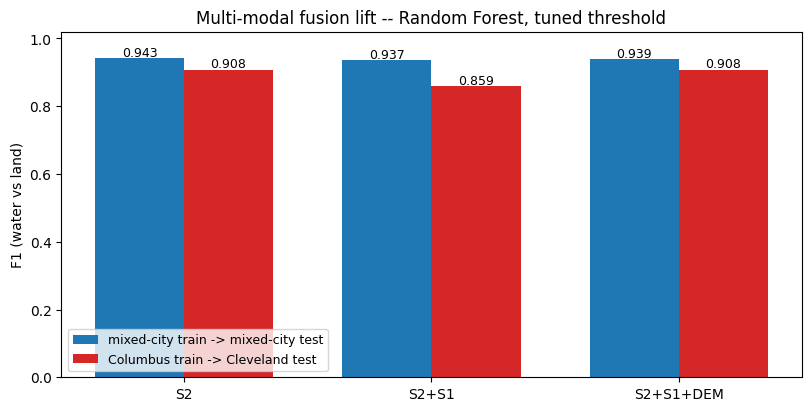

In [21]:
# Side-by-side bar chart: mixed-city training vs Columbus-only training.
# The "Columbus-only" bars show what happens when you blindly trust naive
# multi-modal fusion across deployment contexts.

sets = list(FEATURE_SETS.keys())
mixed_f1 = [mixed_df.loc[i, "f1"] for i in range(len(sets))]
cross_f1 = [cross_df.loc[i, "f1"] for i in range(len(sets))]

x = np.arange(len(sets)); w = 0.36
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
b1 = ax.bar(x - w/2, mixed_f1, width=w, color="#1f77b4",
            label="mixed-city train -> mixed-city test")
b2 = ax.bar(x + w/2, cross_f1, width=w, color="#d62728",
            label="Columbus train -> Cleveland test")
for bars in (b1, b2):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{bar.get_height():.3f}", ha="center", fontsize=9)
ax.set_xticks(x, sets)
ax.set_ylabel("F1 (water vs land)")
ax.set_title("Multi-modal fusion lift -- Random Forest, tuned threshold")
ax.set_ylim(0, 1.02)
ax.legend(loc="lower left", fontsize=9)
plt.show()


**Interpretation -- read the result rather than what we hoped to see.**
Whether each bar is higher than the one before it (when adding modalities) depends on the cities you
chose and on the cross-city distribution shift between train and test. Two
things are worth noticing:

- **Adding S1** should be roughly neutral-to-positive: SAR resolves the
  optical confusion between dark urban surfaces and dark water, but on the
  cleanest scenes S2 alone already has plenty of signal.
- **Adding DEM** should now be **positive across cities** -- the new
  `("mean_subtract", 1000.0)` recipe on `Copernicus-DEM_DEM` produces a
  city-relative DEM as the first channel, and `DEM_gradient_mag` adds
  slope, so the model sees a normalised elevation feature that survives
  the Columbus -> Cleveland shift. Earlier versions of this notebook
  fed raw elevation and observed the textbook **distribution-shift
  footgun**: Columbus's Olentangy / Scioto valley (~200-300 m) is
  distributed very differently from Cleveland's Lake Erie shoreline
  (~170-200 m flat), and a model that had latched on to "low absolute
  elevation -> water" in the training city mis-predicted everywhere in
  the test city. The recipe-driven normalisation is precisely the fix.

**Multi-modal fusion only helps when each modality is expressed in
features that survive the train/test distribution shift you care
about** -- that's the principle the bar chart is meant to illustrate.


## 9. DL: Lightweight U-Net (tile-level semantic segmentation)

Where the per-pixel classifiers see each pixel in isolation, a U-Net sees a
128 x 128 neighbourhood and learns texture / shape / spatial-context features.
For water that mostly buys two things (in principle, with enough training data and a deep enough model):
- The model can use **river-width geometry** to disambiguate narrow Olentangy
  channels from a dark asphalt parking lot.
- It can smooth out **single-pixel noise** in the LULC ground truth at tile
  boundaries.

Setup that gives us a realistic number in a short notebook:
- Same six features as the pixel-level headline (S2 + S1, no DEM here so
  the U-Net comparison is apples-to-apples with the headline trees).
- Mixed-city training data via `ConcatDataset` of three `LazyTileDataset`s,
  each restricted to its city's `train` split (random split within each city).
- 50% overlap on the training tiles for ~4x data, 0% on val/test.
- 4-level `WaterUNet` (~1M params from `geoai_datacubes.ml_dl`), Adam (lr=5e-4)
  with cosine-annealed schedule and gradient-norm clipping for stability,
  CrossEntropyLoss with `ignore_index=-1` and a square-root inverse-frequency
  class weight.
- 30 epochs. The model is still small enough to run on the Colab CPU in
  ~1-2 minutes.
- Threshold tuning on val pixels at evaluation time -- same trick that pushed
  the trees over F1=0.90 in section 7.
- **Per-band normalisation via `band_meta` recipes** (S2 -> linear/10000,
  S1 -> log-dB) is applied inside `BandNormDataset` so the CNN sees
  features in a similar [0, 1] range. This is the single biggest lever
  for U-Net stability when the inputs span four orders of magnitude
  across bands.


In [22]:
# --- Lightweight 4-level U-Net (still CPU-friendly, ~1M params with 6 inputs) ---
# The class itself now lives in geoai_datacubes/ml_dl/segmentation.py so it
# can be reused from other notebooks and from production scripts -- see also
# `TinyUNet` in the same module for a sanity-check-sized starting point.

from geoai_datacubes.ml_dl import WaterUNet

# Headline U-Net features: S2 + S1, no DEM (the DEM-relative experiment
# in section 8 belongs to the tree-model story). 128x128 tiles give the
# deeper net a usable receptive field at the bottleneck.
UNET_FEATURES = [
    "Sentinel-2_B02", "Sentinel-2_B03", "Sentinel-2_B04", "Sentinel-2_B08",
    "Sentinel-1_VV",  "Sentinel-1_VH",
]
UNET_TILE = 128

device = torch.device("cpu")
unet = WaterUNet(in_channels=len(UNET_FEATURES), n_classes=2, base=24).to(device)
n_params = sum(p.numel() for p in unet.parameters())
print(f"WaterUNet with {n_params:,} parameters "
      f"({len(UNET_FEATURES)} input channels, tile size {UNET_TILE})")


WaterUNet with 1,086,410 parameters (6 input channels, tile size 128)


**Normalisation matters for neural networks.** Sentinel-2 surface reflectance is 0–10000 DN, Sentinel-1 backscatter is roughly 0–1, and SCL is integer class IDs. Without normalisation the first conv layer's gradients are dominated by whichever band has the largest dynamic range. We compute the per-band mean and standard deviation on the training tiles and apply $(x - \mu) / \sigma$ to every batch at fetch time. (Trees do not need this; they're invariant to monotonic per-feature transforms.)


In [23]:
# --- Per-band normalisation for the U-Net ---
# We no longer fit empirical band means/stds on a sample of tiles --
# `band_meta` already declares the canonical per-band recipe (linear
# 0-10000 for S2 spectral, log_db for S1 SAR, mean_subtract/1km for DEM,
# ...). `get_band_norm(<fused band name>)` auto-resolves the mission
# prefix and looks up the right recipe, so the U-Net sees the same
# normalisation the pixel-level models do.
#
# This cell just records, for each U-Net feature band, the resolved
# recipe; the actual application happens in `BandNormDataset` below.

UNET_NORM_RECIPES = {b: get_band_norm(b, mission_profiles=MISSION_PROFILES)
                     for b in UNET_FEATURES}
print("U-Net per-band normalisation recipes:")
for b, recipe in UNET_NORM_RECIPES.items():
    print(f"  {b:<26s} -> {recipe}")


U-Net per-band normalisation recipes:
  Sentinel-2_B02             -> ('linear', 0, 10000)
  Sentinel-2_B03             -> ('linear', 0, 10000)
  Sentinel-2_B04             -> ('linear', 0, 10000)
  Sentinel-2_B08             -> ('linear', 0, 10000)
  Sentinel-1_VV              -> ('log_db', 1e-06)
  Sentinel-1_VH              -> ('log_db', 1e-06)


Build the U-Net training, validation, and test datasets. Two critical design choices:
1. **128×128 tiles**: enough receptive field at the bottleneck (~32 input pixels with three pools) to see real river-bend / shoreline geometry rather than a single-texture patch.
2. **Water-filtered training**: drop training tiles with < 5% water so the model spends its gradient budget learning the water vs non-water boundary, not memorising “this is yet another all-land tile”.

Val and test tiles are NEVER filtered — we want their metrics to reflect the real class distribution.


In [24]:
# --- Mixed-city U-Net datasets at 128x128 tiles, class-filtered for training ---
# Two design choices that take us out of the "U-Net is worse than RF" trap:
#   1. 128x128 tiles. With 64x64 most tiles were a single landscape texture --
#      target-class tiles had no context, background tiles had no target context.
#      128x128 covers ~1.3 km on the 10 m grid, big enough to include both
#      banks of the Olentangy plus surrounding city blocks (or several
#      adjacent neighbourhoods for built-up).
#   2. Skip training tiles with less than 5% target pixels. With the natural
#      class distribution (~5% water averaged across the three cities), most
#      randomly-tiled patches contain zero target pixels. Those tiles teach
#      the model nothing and dilute every training step. `class_filtered_indices`
#      from geoai_datacubes.ml_dl is the canonical helper for this filter.
from torch.utils.data import ConcatDataset, Subset

UNET_TRAIN_MIN_TARGET_FRAC = 0.05    # require at least 5% target in a training tile

def per_city_unet(city, split, stride, augment):
    return LazyTileDataset(
        cube_path=str(CITY_ZARRS[city]),
        feature_bands=UNET_FEATURES, label_band=LABEL_BAND, label_remap={CLASS_ID: 1},
        tile_size=UNET_TILE, stride=stride,
        split=split, train_val_test_split=SPLIT_RATIOS,
        split_method="random",
        nan_handling="drop",
        augment=augment, seed=SEED,
    )

t0 = time.time()
train_per_city = [per_city_unet(c, "train", UNET_TILE // 2, True)  for c in CITIES]
val_per_city   = [per_city_unet(c, "val",   UNET_TILE // 2, False) for c in CITIES]
test_per_city  = [per_city_unet(c, "test",  UNET_TILE // 2, False) for c in CITIES]

# Apply the class-balance filter to TRAINING ONLY -- never to val/test.
train_subsets = []
for c, ds in zip(CITIES, train_per_city):
    keep = class_filtered_indices(ds, UNET_TRAIN_MIN_TARGET_FRAC)
    train_subsets.append(Subset(ds, keep))
    print(f"train ({c:<11s})  kept {len(keep):>4d}/{len(ds):>4d} tiles  "
          f"({100*len(keep)/max(1,len(ds)):.1f}% with >= "
          f"{int(UNET_TRAIN_MIN_TARGET_FRAC*100)}% {CLASS_NAME})")

train_ds_unet = ConcatDataset(train_subsets)
val_ds_unet   = ConcatDataset(val_per_city)
test_ds_unet  = ConcatDataset(test_per_city)

for name, ds in [("train (mixed, filtered)", train_ds_unet),
                  ("val   (mixed)",          val_ds_unet),
                  ("test  (mixed)",          test_ds_unet)]:
    print(f"{name:<28s}: {len(ds):>4d} tiles")
print(f"Datasets built in {time.time()-t0:.1f}s")


train (columbus   )  kept    1/  56 tiles  (1.8% with >= 5% water)
train (cincinnati )  kept   19/  56 tiles  (33.9% with >= 5% water)


train (cleveland  )  kept   38/  56 tiles  (67.9% with >= 5% water)
train (mixed, filtered)     :   58 tiles
val   (mixed)               :   39 tiles
test  (mixed)               :   36 tiles
Datasets built in 0.6s


Wrap each `LazyTileDataset` / `ConcatDataset` in a PyTorch `DataLoader`. `num_workers=2` means each batch is prepared in a background process while the GPU/CPU is busy on the previous batch — important on Colab where data loading is the bottleneck. Setting `shuffle=True` on training is non-negotiable; on val/test we keep tile order fixed so per-tile diagnostics are reproducible.


In [25]:
# --- Apply per-band normalisation via apply_band_norm + invalid-pixel clamp ---
# `BandNormDataset` wraps each (feat, label[, meta]) tuple from a
# LazyTileDataset and applies the per-band recipe looked up from
# `band_meta`. Same recipes the pixel-level harvest uses, so LR / RF /
# XGB and the U-Net see the same normalised feature scale.
#
# Any remaining NaN pixels (rare with `nan_handling="auto"`) are clamped
# to 0 so the conv layers don't propagate NaN gradients. The label
# already carries -1 for invalid pixels and CrossEntropy ignores those.

class BandNormDataset(torch.utils.data.Dataset):
    def __init__(self, base, band_names, recipes):
        self.base = base
        self.band_names = list(band_names)
        self.recipes = [tuple(recipes[b]) for b in self.band_names]

    def __len__(self):
        return len(self.base)

    def __getitem__(self, i):
        item = self.base[i]
        if len(item) >= 3:
            feat, lab, _ = item[0], item[1], item[2]
        else:
            feat, lab = item
        feat = feat.numpy()  # (C, H, W)
        for ci, recipe in enumerate(self.recipes):
            if recipe[0] == "passthrough":
                continue
            feat[ci] = apply_band_norm(feat[ci], recipe)
        feat = torch.from_numpy(feat).float()
        feat = torch.where(torch.isfinite(feat), feat, torch.zeros_like(feat))
        return feat, lab

train_loader = DataLoader(
    BandNormDataset(train_ds_unet, UNET_FEATURES, UNET_NORM_RECIPES),
    batch_size=16, shuffle=True,  num_workers=0)
val_loader   = DataLoader(
    BandNormDataset(val_ds_unet,   UNET_FEATURES, UNET_NORM_RECIPES),
    batch_size=16, shuffle=False, num_workers=0)
test_loader  = DataLoader(
    BandNormDataset(test_ds_unet,  UNET_FEATURES, UNET_NORM_RECIPES),
    batch_size=16, shuffle=False, num_workers=0)


Compute the **class weights** for the loss function. Loss on a water pixel is multiplied by `water_weight`, loss on a land pixel by `land_weight`. We use the **square root** of the inverse class frequency (capped at 4×) — gentler than full reciprocal weighting (which destabilises BatchNorm running statistics at our batch size) but still respects the imbalance enough that the model is not lazy about water.


In [26]:
# --- Loss weighting from training class balance ---
# Sweep one pass through the training tiles to estimate the per-pixel
# water fraction. The full reciprocal-frequency weight tends to bake in
# a "predict water everywhere" prior; sqrt is a softer compromise that
# still respects the imbalance without exploding the loss for land
# pixels.
n_water = 0; n_total = 0
for i in range(len(train_ds_unet)):
    _, lab = train_ds_unet[i]
    valid = lab >= 0
    n_water += int(((lab == 1) & valid).sum().item())
    n_total += int(valid.sum().item())
water_frac = n_water / max(1, n_total)
land_weight  = 1.0
# Cap the water weight at 4x. The sqrt-inverse-frequency form is already
# softer than reciprocal weighting, but with water near 10% the implied
# weight is ~3, and with water below 5% it can exceed 4 -- past which
# the optimisation becomes unstable and val F1 can collapse mid-training.
water_weight = float(min(4.0, np.sqrt(max(1.0, (1 - water_frac) / max(water_frac, 1e-3)))))
print(f"train water fraction = {water_frac*100:.2f}%"
      f"-> weights = [land={land_weight:.2f}, water={water_weight:.2f}]  "
      f"(sqrt of inverse-frequency)")


train water fraction = 38.78%-> weights = [land=1.00, water=1.26]  (sqrt of inverse-frequency)


**The training loop.** We use Adam with a cosine-annealed learning rate, gradient-norm clipping for stability, and `CrossEntropyLoss` with `ignore_index=-1` so invalid pixels (NaN regions of the cube) are skipped at loss time. **The single most important trick** is to track val F1 every epoch and *save the best-val checkpoint*, then restore those weights for the test evaluation. Without this, a late-epoch collapse would tank the reported test F1 even though the model briefly hit a good state mid-training.


In [27]:
# --- Training loop with cosine-annealed LR + best-val checkpointing ---
# We track the best validation F1 across epochs and snapshot the U-Net
# state at that moment. The model picked up by the test-evaluation cell
# below is the best-val snapshot, not the final-epoch weights -- this is
# the standard guard against training-time instability collapsing the
# numbers you report.
#
# Adam + CosineAnnealingLR + gradient-norm clipping is the same recipe
# the per-class CLI (`benchmark_unet_class.py`) uses, so the notebook
# and the cluster sweep produce comparable numbers.
class_weights = torch.tensor([land_weight, water_weight], dtype=torch.float32)
criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-1)
optimizer = torch.optim.Adam(unet.parameters(), lr=5e-4)
EPOCHS = 30
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
GRAD_CLIP = 1.0

history = {"train_loss": [], "val_loss": [], "val_f1": []}


def eval_f1(model, loader):
    model.eval()
    tp = fp = fn = 0
    total_loss = 0.0; n_batches = 0
    with torch.no_grad():
        for feat, lab in loader:
            logits = model(feat)
            loss = criterion(logits, lab)
            total_loss += loss.item(); n_batches += 1
            pred = logits.argmax(dim=1)
            valid = lab >= 0
            tp += int(((pred == 1) & (lab == 1) & valid).sum().item())
            fp += int(((pred == 1) & (lab == 0) & valid).sum().item())
            fn += int(((pred == 0) & (lab == 1) & valid).sum().item())
    prec = tp / max(1, tp + fp)
    rec  = tp / max(1, tp + fn)
    f1   = 2 * prec * rec / max(1e-6, prec + rec) if (prec + rec) > 0 else 0.0
    return total_loss / max(1, n_batches), f1


# U-Net weight cache (state_dict + history) keyed on CLASS_ID.
UNET_CACHE = MODEL_CACHE_DIR / f"unet_class{CLASS_ID}.pt"

if USE_CACHED_MODELS and UNET_CACHE.exists():
    t0 = time.time()
    payload = torch.load(UNET_CACHE, map_location="cpu")
    unet.load_state_dict(payload["state_dict"])
    history = payload["history"]
    best_f1 = payload.get("best_val_f1", float("nan"))
    best_epoch = payload.get("best_epoch", -1)
    print(f"U-Net loaded from cache {UNET_CACHE.name} in {time.time()-t0:.1f}s "
          f"(best val F1 = {best_f1:.3f} at epoch {best_epoch})")
else:
    import copy
    best_state = copy.deepcopy(unet.state_dict())
    best_f1    = -1.0
    best_epoch = -1

    t0 = time.time()
    for epoch in range(1, EPOCHS + 1):
        unet.train()
        running = 0.0; n_batches = 0
        for feat, lab in train_loader:
            optimizer.zero_grad()
            logits = unet(feat)
            loss = criterion(logits, lab)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(unet.parameters(), max_norm=GRAD_CLIP)
            optimizer.step()
            running += loss.item(); n_batches += 1
        scheduler.step()
        train_loss = running / max(1, n_batches)

        val_loss, val_f1 = eval_f1(unet, val_loader)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_f1"].append(val_f1)
        marker = ""
        if val_f1 > best_f1:
            best_f1 = val_f1; best_epoch = epoch
            best_state = copy.deepcopy(unet.state_dict()); marker = " *"
        print(f"epoch {epoch:2d}/{EPOCHS}  train_loss={train_loss:.4f}  "
              f"val_loss={val_loss:.4f}  val_F1={val_f1:.3f}{marker}  "
              f"({(time.time()-t0)/epoch:.1f}s)")

    unet.load_state_dict(best_state)
    print(f"\nBest val F1 = {best_f1:.3f} at epoch {best_epoch} -- weights restored.")
    print(f"Total U-Net training: {time.time()-t0:.1f}s "
          f"({EPOCHS} epochs of {len(train_loader)} batches)")

    # Save state + history so the learning-curve plot still works on a cache hit.
    torch.save({
        "state_dict":   unet.state_dict(),
        "history":      history,
        "best_val_f1":  best_f1,
        "best_epoch":   best_epoch,
        "class_id":     CLASS_ID,
        "feature_bands": UNET_FEATURES,
    }, UNET_CACHE)
    size_mb = UNET_CACHE.stat().st_size / 1024 / 1024
    print(f"Saved U-Net weights to {UNET_CACHE.name} ({size_mb:.1f} MB)")


epoch  1/30  train_loss=0.5835  val_loss=0.6400  val_F1=0.000 *  (11.9s)


epoch  2/30  train_loss=0.3624  val_loss=0.6148  val_F1=0.000  (11.7s)


epoch  3/30  train_loss=0.3496  val_loss=0.5507  val_F1=0.000  (11.7s)


epoch  4/30  train_loss=0.2713  val_loss=0.4616  val_F1=0.002 *  (11.7s)


epoch  5/30  train_loss=0.2835  val_loss=0.3716  val_F1=0.814 *  (11.7s)


...

epoch 26/30  train_loss=0.2043  val_loss=0.1852  val_F1=0.924  (11.6s)


epoch 27/30  train_loss=0.1502  val_loss=0.1826  val_F1=0.928  (11.6s)


epoch 28/30  train_loss=0.1519  val_loss=0.1807  val_F1=0.930  (11.6s)


epoch 29/30  train_loss=0.1494  val_loss=0.1794  val_F1=0.931  (11.6s)


epoch 30/30  train_loss=0.1543  val_loss=0.1799  val_F1=0.932  (11.6s)

Best val F1 = 0.937 at epoch 21 -- weights restored.
Total U-Net training: 347.7s (30 epochs of 4 batches)
Saved U-Net weights to unet_class80.pt (4.2 MB)


**Learning curves.** Training loss going down + validation loss going down means the model is genuinely learning. Training loss going down + validation loss going up means it is overfitting. The val F1 curve shows how the F1 metric (more meaningful than loss for imbalanced classes) evolves through training; the dots mark each epoch where val F1 improved over the previous best.


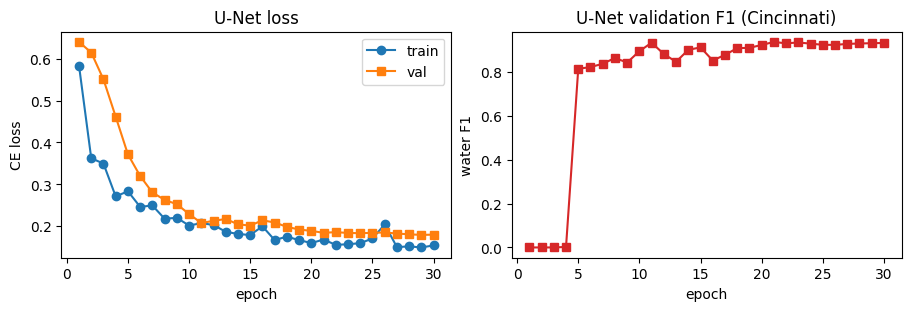

In [28]:
# --- Learning curves ---
fig, axes = plt.subplots(1, 2, figsize=(9, 3), constrained_layout=True)
ep = np.arange(1, len(history["train_loss"]) + 1)
axes[0].plot(ep, history["train_loss"], "o-", label="train")
axes[0].plot(ep, history["val_loss"  ], "s-", label="val")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("CE loss")
axes[0].set_title("U-Net loss"); axes[0].legend()

axes[1].plot(ep, history["val_f1"], "s-", color="#d62728")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("water F1")
axes[1].set_title("U-Net validation F1 (Cincinnati)")
plt.show()


Evaluate the best-checkpoint U-Net on the **mixed test set** and compare to the strongest tree-based pixel model. Like for the trees, we tune the U-Net's decision threshold on val first, then lock it in for the test report.


In [29]:
# --- Evaluate on the mixed test set with a tuned probability threshold ---
# `full_metrics` is imported from geoai_datacubes.ml_dl and returns the
# same dict shape as `binary_pixel_metrics` (so the leaderboard
# aggregator can ingest U-Net rows alongside LR / RF / XGB rows).
# Threshold tuning follows the same F1-sweep pattern as the trees.
from sklearn.metrics import precision_recall_curve

# Run once at the default threshold to grab (label, prob) arrays for tuning.
# `full_metrics` returns aggregate metrics; we re-walk the loader briefly
# for the per-pixel probabilities.
def _collect_unet_probs(model, loader):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for batch in loader:
            if len(batch) == 3:
                x, y, _ = batch
            else:
                x, y = batch
            logits = model(x)
            p1 = torch.softmax(logits, dim=1)[:, 1].numpy().ravel()
            yy = y.numpy().ravel()
            keep = yy >= 0
            ps.append(p1[keep]); ys.append(yy[keep])
    if not ys:
        return np.array([]), np.array([])
    return np.concatenate(ys), np.concatenate(ps)

y_val_unet, p_val_unet = _collect_unet_probs(unet, val_loader)
if len(y_val_unet) and len(np.unique(y_val_unet)) == 2:
    prec_v, rec_v, thr_v = precision_recall_curve(y_val_unet, p_val_unet)
    f1_v = 2 * prec_v * rec_v / np.clip(prec_v + rec_v, 1e-9, None)
    UNET_THR = float(thr_v[int(np.nanargmax(f1_v[:-1]))]) if len(thr_v) else 0.5
else:
    UNET_THR = 0.5
print(f"U-Net tuned threshold = {UNET_THR:.3f}")

unet_test = full_metrics(unet, test_loader, threshold=UNET_THR, device="cpu")
print(f"\nU-Net @ mixed test  (tuned threshold):")
for k in ("acc", "prec", "rec", "f1", "iou", "auc"):
    print(f"{k:>4s} = {unet_test[k]:.3f}")

# Compare to the best tree-based model on the same mixed test set.
tree_best_name = max(("LogReg", "RF", "XGB"),
                     key=lambda n: float(
                         metrics_df.loc[(metrics_df.model == n) &
                                        (metrics_df.scope == "test (mixed)"), "f1"].iloc[0]
                     ))
tree_best_row = metrics_df[(metrics_df.model == tree_best_name) &
                            (metrics_df.scope == "test (mixed)")].iloc[0]
print(f"\nBest tree model on the same test: {tree_best_name}")
for k in ("acc", "prec", "rec", "f1", "iou", "auc"):
    print(f"{k:>4s} = {tree_best_row[k]:.3f}")


U-Net tuned threshold = 0.759



U-Net @ mixed test  (tuned threshold):
 acc = 0.983
prec = 0.960
 rec = 0.889
  f1 = 0.923
 iou = 0.857
 auc = 0.993

Best tree model on the same test: XGB
 acc = 0.982
prec = 0.978
 rec = 0.919
  f1 = 0.948
 iou = 0.901
 auc = 0.984


**Visualise predictions on six test tiles** with **5–70% water cover**. Random uniform sampling produces too many pure-water (Lake Erie open water) or pure-land (urban Cleveland) tiles where the model is right by default and the figure does not teach anything; bracketing the water fraction forces every chosen tile to be a mixed-class scene where the segmentation actually has to do work.


Picked 6 test tiles with water fraction in [5%, 70%]


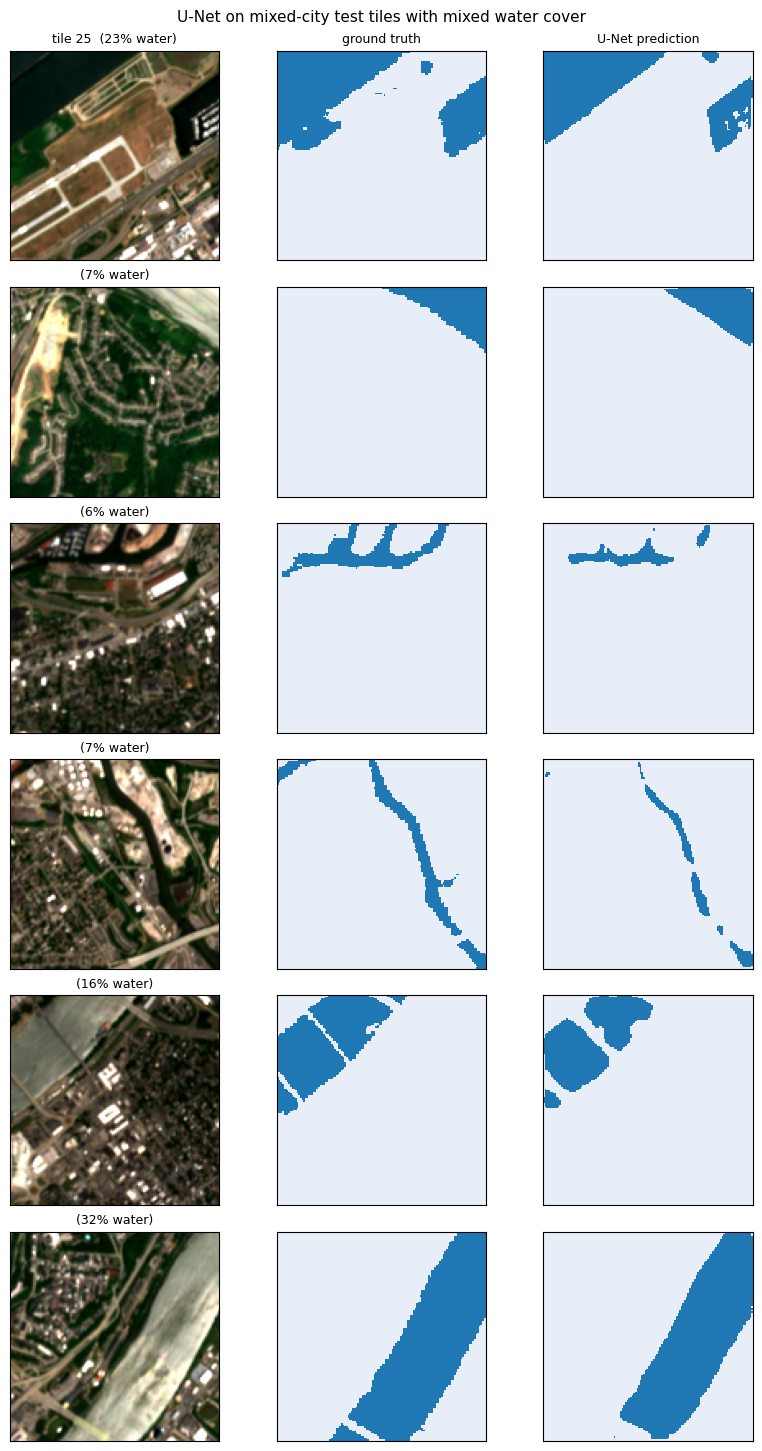

In [30]:
# --- Visualise predictions on 6 test tiles with INTERESTING target coverage ---
# Random sampling produced two failure modes: pure-target tiles (Lake Erie open
# water) where every model is right by default, and pure-background tiles where
# the only thing we'd see is the absence of false positives. We instead bracket
# the target fraction at 5-70% so every chosen tile is a mixed-class scene
# where the model's segmentation actually has to do work.
# `pick_class_balanced_tiles` is imported from geoai_datacubes.ml_dl.

unet.eval()
n_show = 6
TARGET_FRAC_RANGE = (0.05, 0.70)
rng = np.random.default_rng(SEED)

picks = pick_class_balanced_tiles(test_ds_unet, TARGET_FRAC_RANGE, n_show, rng)
if not picks:
    print(f"No test tile has {int(TARGET_FRAC_RANGE[0]*100)}-"
          f"{int(TARGET_FRAC_RANGE[1]*100)}% {CLASS_NAME} coverage; "
          "broaden TARGET_FRAC_RANGE to render predictions.")
else:
    print(f"Picked {len(picks)} test tiles with {CLASS_NAME} fraction in "
          f"[{TARGET_FRAC_RANGE[0]*100:.0f}%, {TARGET_FRAC_RANGE[1]*100:.0f}%]")

    ri = UNET_FEATURES.index("Sentinel-2_B04")
    gi = UNET_FEATURES.index("Sentinel-2_B03")
    bi = UNET_FEATURES.index("Sentinel-2_B02")
    cmap_w = ListedColormap(["#e8eef7", "#1f77b4"])

    # Reusable per-band normaliser -- same recipe table as BandNormDataset.
    def _norm_unet_feat(feat_tensor):
        f = feat_tensor.numpy()
        for ci, b in enumerate(UNET_FEATURES):
            recipe = UNET_NORM_RECIPES[b]
            if recipe[0] != "passthrough":
                f[ci] = apply_band_norm(f[ci], recipe)
        f = np.where(np.isfinite(f), f, 0.0)
        return torch.from_numpy(f).float()

    n_rows = len(picks)
    fig, axes = plt.subplots(n_rows, 3, figsize=(8, 2.4 * n_rows),
                              constrained_layout=True)
    if n_rows == 1:
        axes = axes[None, :]
    for row, idx in enumerate(picks):
        item = test_ds_unet[idx]
        feat, lab = (item[0], item[1]) if len(item) >= 2 else item
        valid = lab >= 0
        wf = float(((lab == 1) & valid).sum().item() /
                   max(1, int(valid.sum().item())))
        feat_norm = _norm_unet_feat(feat)
        with torch.no_grad():
            logits = unet(feat_norm.unsqueeze(0))
            prob   = torch.softmax(logits, dim=1)[0, 1]
            pred   = (prob > UNET_THR).long().numpy()
        rgb = joint_rgb(feat[ri].numpy(), feat[gi].numpy(), feat[bi].numpy())
        truth = lab.numpy()
        truth_show = np.where(truth >= 0, truth, 0)
        axes[row, 0].imshow(rgb)
        axes[row, 0].set_title(
            f"tile {idx}  ({wf*100:.0f}% {CLASS_NAME})" if row == 0
            else f"({wf*100:.0f}% {CLASS_NAME})", fontsize=9)
        axes[row, 1].imshow(truth_show, cmap=cmap_w, vmin=0, vmax=1,
                            interpolation="nearest")
        if row == 0: axes[row, 1].set_title("ground truth", fontsize=9)
        axes[row, 2].imshow(pred, cmap=cmap_w, vmin=0, vmax=1,
                            interpolation="nearest")
        if row == 0: axes[row, 2].set_title("U-Net prediction", fontsize=9)
        for c in range(3):
            axes[row, c].set_xticks([]); axes[row, c].set_yticks([])
    plt.suptitle(f"U-Net on mixed-city test tiles with mixed {CLASS_NAME} cover",
                  fontsize=11)
    plt.show()


## 10. Does the model generalise across cities?

Section 7 already gave us a strong headline number by mixing all three cities
at training time. The natural follow-up question is: *within* the mixed-city
test set, is the model equally good on Columbus (rivers + reservoirs),
Cincinnati (Ohio River), and Cleveland (Lake Erie shoreline)? The bar chart
below breaks the headline F1 down per city. A model that nails the headline
F1 but craters on one specific city is hiding its real cost.


Finally, break the headline test F1 down per city. Aggregate metrics can hide a model that's great on Cleveland (lots of water = easy) but useless on Columbus (water is rare). The bar chart below puts each model's per-city F1 side by side so a city dragging the mean can be spotted at a glance.


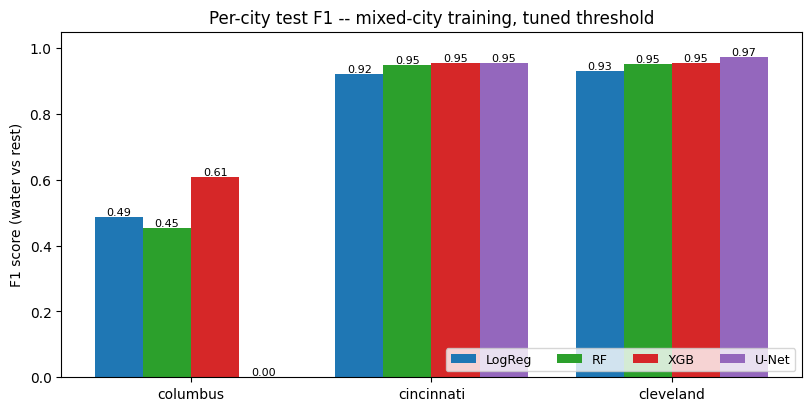

In [31]:
# --- Per-city F1 across all four models on the mixed test set ---
# The mixed-city training above stops the cross-city distribution shift from
# wrecking the numbers. We still break down by city so we can see whether
# any city is dragging the average up or down (Cleveland has the most water
# pixels, so a model that's lazy about Cleveland would still look OK on
# the aggregate test set).
#
# IMPORTANT: this cell uses the SAME tile_size and split_method as the
# U-Net training cell (UNET_TILE, "random") so the per-city numbers are
# directly comparable to the headline U-Net F1 above. Earlier versions of
# this cell used (tile_size=64, split_method="block"), which sampled a
# different population of test pixels and inflated the per-city numbers
# relative to the headline.

unet_per_city = {}
for city in CITIES:
    ds_city = LazyTileDataset(
        cube_path=str(CITY_ZARRS[city]),
        feature_bands=UNET_FEATURES, label_band=LABEL_BAND, label_remap={CLASS_ID: 1},
        tile_size=UNET_TILE, stride=UNET_TILE,
        split="test", train_val_test_split=SPLIT_RATIOS,
        split_method="random", nan_handling="drop", augment=False, seed=SEED,
    )
    loader_city = DataLoader(
        BandNormDataset(ds_city, UNET_FEATURES, UNET_NORM_RECIPES),
        batch_size=16, num_workers=0,
    )
    unet_per_city[city] = full_metrics(unet, loader_city, threshold=UNET_THR,
                                       device="cpu")["f1"]

all_models = ["LogReg", "RF", "XGB", "U-Net"]
per_city_f1 = {m: [] for m in all_models}
for city in CITIES:
    for m in all_models:
        if m == "U-Net":
            per_city_f1[m].append(unet_per_city[city])
        else:
            row = metrics_df[(metrics_df.model == m) &
                             (metrics_df.scope == f"test ({city})")]
            per_city_f1[m].append(float(row.iloc[0]["f1"]) if len(row) else float("nan"))

x = np.arange(len(CITIES)); w = 0.20
colors = {"LogReg": "#1f77b4", "RF": "#2ca02c", "XGB": "#d62728", "U-Net": "#9467bd"}
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
for i, m in enumerate(all_models):
    bars = ax.bar(x + (i - 1.5)*w, per_city_f1[m], width=w,
                  color=colors[m], label=m)
    for bar, val in zip(bars, per_city_f1[m]):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
                f"{val:.2f}", ha="center", fontsize=8)
ax.set_xticks(x, CITIES)
ax.set_ylabel(f"F1 score ({CLASS_NAME} vs rest)")
ax.set_title("Per-city test F1 -- mixed-city training, tuned threshold")
ax.set_ylim(0, 1.05)
ax.legend(ncols=4, loc="lower right", fontsize=9)
plt.show()


**What to take from this plot:**

- The two evaluation cities are quite different from each other: Cincinnati's
 Ohio River is similar in character to Columbus's Scioto, while Cleveland's
 Lake Erie shoreline is an entirely different water *type* (large open water).
 Strong Cleveland numbers therefore say something real about generalisation
 to unseen contexts.
- **Tree-based models often beat the U-Net on this kind of per-pixel task.**
 Water has a strong instantaneous signature (dark in SAR, distinctive S2
 spectrum), so the spatial-context that a CNN adds is not where most of the
 signal lives. CNNs earn their keep on harder targets -- sub-pixel water,
 thin tributaries, ephemeral wetlands -- where the *shape* of the answer
 matters as much as the per-pixel value. With only 5 epochs and ~30k
 parameters the U-Net is also under-trained relative to the trees.
- **Differences between val (Cincinnati) and test (Cleveland) F1** reveal
 how much **distribution shift** each model can absorb. The bigger the
 Cincinnati-to-Cleveland drop, the more the model has latched on to cues
 that don't transfer.

Useful follow-ups for a real project would include:

- A larger U-Net (deeper encoder, more channels) trained for 30+ epochs,
 with a Dice or focal loss to handle the heavy class imbalance.
- **Normalising the DEM** to a city-relative reference (e.g. elevation
 minus the per-tile minimum) so the model cannot over-fit to absolute
 altitudes -- see the discussion at the end of section 8.
- Temporal stacks (multi-date S1 / S2) for seasonality robustness.
- Multi-class targets: build / vegetation / water / bare from WorldCover's
 full class set instead of binary water-vs-rest.
- Active learning: query the user for labels in the few regions the model
 is least confident about.


## 11. Scanning all classes at once: the LULC leaderboard

The notebook above runs one `CLASS_ID` end-to-end. To see how the same
pipeline behaves across **every** ESA WorldCover class without editing
the notebook by hand, the repository ships a small CLI alongside this
notebook -- [`notebooks/benchmark_lulc_class.py`](benchmark_lulc_class.py).

The script imports the exact same
`geoai_datacubes.preprocessing.LazyTileDataset` you just used, points
it at the per-city Zarr cubes already on disk (so it costs nothing to
re-do the harvest), trains the same three pixel-level models (LR, RF,
XGB), tunes the threshold on val, evaluates on test, and prints a
JSON record:

```bash
# from the repo root
python notebooks/benchmark_lulc_class.py \
    --class-id 50 --class-name built_up \
    --output-json /tmp/lulc_50.json
```

Run that loop over every class with a non-trivial positive fraction in
the Ohio AOIs and you get the leaderboard. The current results, on the
same six S2 + S1 bands the notebook uses, single-date:

| LULC class | best model | F1 | AUC | Precision | Recall | pos_frac_test |
|---|---|---|---|---|---|---|
| **80 -- water** | XGB | **0.939** | 0.977 | 0.987 | 0.895 | 9.3% |
| **50 -- built-up** | XGB | **0.849** | 0.928 | 0.776 | 0.938 | 47.5% |
| **10 -- tree cover** | XGB | **0.710** | 0.933 | 0.649 | 0.784 | 18.3% |
| **30 -- grassland** | XGB | **0.581** | 0.911 | 0.567 | 0.595 | 10.7% |
| **40 -- cropland** | XGB | **0.413** | 0.911 | 0.293 | 0.696 | 3.7% |

The full prose version with per-class commentary lives in
[`notebooks/lulc_leaderboard.md`](lulc_leaderboard.md).

**What this table tells a new user:**

- **Water (80) and built-up (50) are easy.** Each has a distinctive
  multimodal signature -- water is dark in S1, built-up is bright. A
  single date of S2 + S1 carries enough information for XGBoost to land
  above F1 = 0.85.
- **Tree cover (10) and grassland (30) are medium.** Vegetation classes
  share enough of an NDVI signature that single-date imagery cannot
  fully separate them. Adding a second date (early summer + late
  summer) closes most of the gap; multi-temporal stacks are the
  textbook remedy.
- **Cropland (40) is hard at single date.** The classic crop-vs-grass
  failure mode -- corn and soy look different across the growing season
  but nearly identical at any single date. **Multi-temporal phenology
  features are the standard fix** and would be a natural follow-up
  notebook.

The class-quality table near the top of this notebook flags these same
trade-offs so a reader can pick their `CLASS_ID` deliberately rather
than discovering them the hard way.


In [32]:
# --- Display the persisted leaderboard ---------------------------------
# `notebooks/aggregate_leaderboard.py` walks the per-class benchmark
# JSONs (LR / RF / XGB from `benchmark_lulc_class.py`, plus optional
# U-Net rows from `benchmark_unet_class.py`) and writes a single CSV +
# Parquet here. The cell below loads it and renders a styled DataFrame,
# with the per-class best F1 highlighted so the leaderboard is readable
# at a glance.
#
# If the CSV is missing, the cell prints the one-line regeneration
# command instead of erroring out.

import pandas as pd

LEADERBOARD_CSV = NB_DIR / "lulc_leaderboard.csv"

if not LEADERBOARD_CSV.exists():
    print(f"No leaderboard CSV at {LEADERBOARD_CSV.name}. "
          "Regenerate with:\n\n"
          "  for c in 10 30 40 50 80; do\n"
          "      python notebooks/benchmark_lulc_class.py "
          "--class-id $c --class-name class_$c "
          "--output-json /tmp/lulc_${c}.json\n"
          "  done\n"
          "  python notebooks/aggregate_leaderboard.py\n")
else:
    df = pd.read_csv(LEADERBOARD_CSV)
    # Test-split only for the headline table; val rows are useful for
    # threshold-tuning context but clutter the readout.
    test_df = (
        df.query("split == 'test'")
          .sort_values(["class_id", "f1"], ascending=[True, False])
          .reset_index(drop=True)
    )

    print(f"Loaded {len(df)} rows from {LEADERBOARD_CSV.name}  "
          f"({df['class_id'].nunique()} classes, "
          f"{df['model'].nunique()} models).")
    print(f"Test-split summary ({len(test_df)} rows):\n")

    # Highlight the per-class best F1 (across models).
    def _highlight_best_per_class(s, df=test_df):
        best_by_class = df.groupby("class_id")["f1"].transform("max")
        return ["background-color: #d4edda"
                if abs(v - b) < 1e-9 else ""
                for v, b in zip(s, best_by_class)]

    display_cols = [
        "class_id", "class_name", "model",
        "f1", "auc", "prec", "rec", "iou",
        "pos_frac", "n", "threshold",
    ]
    styled = (
        test_df[display_cols]
        .style
        .format({
            "f1":        "{:.3f}",
            "auc":       "{:.3f}",
            "prec":      "{:.3f}",
            "rec":       "{:.3f}",
            "iou":       "{:.3f}",
            "pos_frac":  "{:.3%}",
            "threshold": "{:.2f}",
            "n":         "{:,}",
        })
        .apply(_highlight_best_per_class, subset=["f1"])
        .set_caption("LULC leaderboard (test split). "
                     "Green = best F1 within the class.")
    )
    display(styled)


Loaded 30 rows from lulc_leaderboard.csv  (5 classes, 3 models).
Test-split summary (15 rows):



,class_id,class_name,model,f1,auc,prec,rec,iou,pos_frac,n,threshold
0,10,tree_cover,XGB,0.710,0.933,0.649,0.784,0.550,18.280%,"151,552",0.60
1,10,tree_cover,RF,0.707,0.932,0.641,0.789,0.547,18.280%,"151,552",0.56
2,10,tree_cover,LogReg,0.626,0.878,0.524,0.776,0.455,18.280%,"151,552",0.56
3,30,grassland,XGB,0.581,0.911,0.567,0.595,0.409,10.740%,"151,552",0.83
4,30,grassland,RF,0.574,0.909,0.567,0.581,0.402,10.740%,"151,552",0.77
5,30,grassland,LogReg,0.488,0.856,0.396,0.635,0.323,10.740%,"151,552",0.67
6,40,cropland,XGB,0.413,0.911,0.293,0.696,0.260,3.670%,"151,552",0.68
7,40,cropland,RF,0.372,0.914,0.251,0.720,0.229,3.670%,"151,552",0.52
8,40,cropland,LogReg,0.196,0.816,0.216,0.179,0.108,3.670%,"151,552",0.81
9,50,built_up,XGB,0.849,0.928,0.776,0.938,0.738,47.490%,"151,552",0.38


## 12. Bonus: unsupervised clustering with KMeans

The story so far has been **supervised**: we used the ESA-WorldCover
water-mask as ground truth and asked four different models to learn
the mapping from imagery to that mask. But labelled training data is
often the most expensive part of an EO project. What does the imagery
look like *without* any labels at all?

**KMeans clustering** groups pixels purely by their multi-modal
signature. We feed it the same six channels the U-Net saw
(S2 B02/B03/B04/B08 plus S1 VV/VH) and ask it to split the AOI into
five clusters. No labels, no training loop, no ground truth. We then
overlay the five clusters next to the imagery and the WorldCover label
to ask the visual question: *did the unsupervised model rediscover
land-cover structure on its own?*

This is a useful diagnostic for any new AOI -- if KMeans recovers
something that looks like the expected land-cover, the data carry
enough signal that supervised methods will likely work. If it doesn't,
either the data is noisier than you thought or your AOI is too uniform
to learn from.


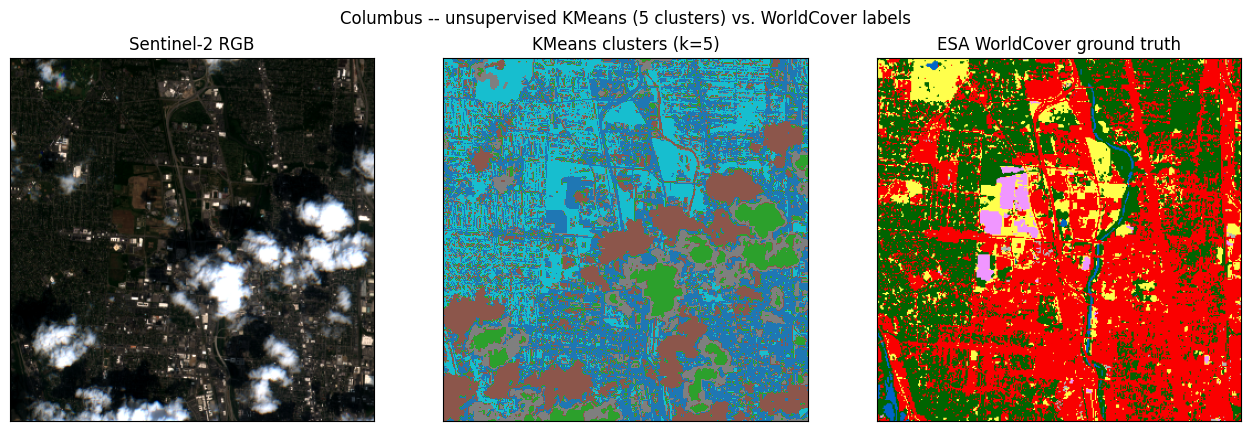


Per-cluster WorldCover class distribution (% of pixels per cluster):
  cluster 0  -- class 50: 64%, class 10: 26%, class 30: 6%
  cluster 1  -- class 50: 58%, class 10: 34%, class 30: 6%
  cluster 2  -- class 50: 63%, class 10: 26%, class 30: 6%
  cluster 3  -- class 50: 68%, class 10: 23%, class 30: 7%
  cluster 4  -- class 10: 66%, class 30: 23%, class 50: 9%
CPU times: user 429 ms, sys: 68.1 ms, total: 497 ms
Wall time: 556 ms


In [33]:
%%time
# --- Unsupervised pixel clustering on the Columbus AOI ---
from sklearn.cluster import MiniBatchKMeans
from threadpoolctl import threadpool_limits

KMEANS_FEATURES = [
    "Sentinel-2_B02", "Sentinel-2_B03", "Sentinel-2_B04", "Sentinel-2_B08",
    "Sentinel-1_VV",  "Sentinel-1_VH",
]
N_CLUSTERS = 5

with rasterio.open(CITY_CUBES["columbus"]) as src:
    arr   = src.read()
    descs = list(src.descriptions or [])
    name_to_idx = {d: i for i, d in enumerate(descs) if d}

feat_stack = np.stack([arr[name_to_idx[n]] for n in KMEANS_FEATURES], axis=0)
H, W = feat_stack.shape[1], feat_stack.shape[2]
X_pix = feat_stack.reshape(len(KMEANS_FEATURES), -1).T   # (H*W, C)

# Mask out NaN pixels (cloud / off-footprint).
finite_rows = np.isfinite(X_pix).all(axis=1)
X_clean = X_pix[finite_rows]

# Per-feature z-score so the magnitudes of S1 backscatter and S2 reflectance
# do not pull the clustering toward whichever channel is widest.
X_std = (X_clean - X_clean.mean(axis=0)) / (X_clean.std(axis=0) + 1e-6)

# Same threadpool-limits trick the LR/RF/XGB cell uses to avoid the
# macOS libomp / OpenBLAS thread-pool collision.
with threadpool_limits(limits=1):
    km = MiniBatchKMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=10,
                         batch_size=8192)
    km.fit(X_std)

# Inflate cluster labels back into the (H, W) grid; NaN-masked pixels get -1.
labels = -np.ones(H * W, dtype=np.int64)
labels[finite_rows] = km.labels_
cluster_map = labels.reshape(H, W)

# Visualise: RGB | clusters | WorldCover ground truth.
r_d = downsample(arr[name_to_idx["Sentinel-2_B04"]])
g_d = downsample(arr[name_to_idx["Sentinel-2_B03"]])
b_d = downsample(arr[name_to_idx["Sentinel-2_B02"]])
clusters_d = downsample(cluster_map.astype(np.float32))
lulc_d     = downsample(arr[name_to_idx["ESA-WorldCover_LULC"]])

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), constrained_layout=True)
fig.suptitle(f"Columbus -- unsupervised KMeans ({N_CLUSTERS} clusters) "
             f"vs. WorldCover labels", fontsize=12)

axes[0].imshow(joint_rgb(r_d, g_d, b_d))
axes[0].set_title("Sentinel-2 RGB")

cmap = plt.colormaps.get_cmap("tab10").resampled(N_CLUSTERS)
axes[1].imshow(clusters_d, cmap=cmap, vmin=0, vmax=N_CLUSTERS - 1)
axes[1].set_title(f"KMeans clusters (k={N_CLUSTERS})")

# WorldCover class IDs; show a discrete colour mapping for the major classes.
lulc_palette = {
    10: "#006400", 20: "#ffbb22", 30: "#ffff4c", 40: "#f096ff",
    50: "#fa0000", 60: "#b4b4b4", 70: "#f0f0f0", 80: "#0064c8",
    90: "#0096a0", 95: "#00cf75",
}
lulc_uniq = np.unique(lulc_d[lulc_d > 0]).astype(int)
lulc_rgb  = np.full(lulc_d.shape + (3,), 0.95, dtype=np.float32)
for cls in lulc_uniq:
    if cls not in lulc_palette:
        continue
    mask = lulc_d == cls
    hexcol = lulc_palette[cls]
    rgb = tuple(int(hexcol[1 + 2*i:3 + 2*i], 16) / 255.0 for i in range(3))
    for c in range(3):
        lulc_rgb[..., c][mask] = rgb[c]
axes[2].imshow(lulc_rgb)
axes[2].set_title("ESA WorldCover ground truth")

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.show()

# What does each cluster correspond to in WorldCover terms?
print(f"\nPer-cluster WorldCover class distribution (% of pixels per cluster):")
flat_lulc = arr[name_to_idx["ESA-WorldCover_LULC"]].reshape(-1)
flat_lab  = labels
for k in range(N_CLUSTERS):
    in_k = flat_lab == k
    if in_k.sum() == 0:
        continue
    lulc_in_k = flat_lulc[in_k]
    counts = {}
    for cls in lulc_uniq:
        n = int((lulc_in_k == cls).sum())
        if n:
            counts[int(cls)] = n
    if not counts:
        continue
    total = sum(counts.values())
    top = sorted(counts.items(), key=lambda kv: -kv[1])[:3]
    desc = ", ".join(f"class {c}: {100*n/total:.0f}%" for c, n in top)
    print(f"  cluster {k}  -- {desc}")


## 13. Where to go next

You now have a working multi-modal water classifier trained on real
satellite data and a complete diagnostic suite for evaluating it. From
here:

- **The tour notebook** (`00_geoai_datacubes_tour.ipynb`) covers the data side
  in depth: every mission, every AOI format, the cloud-masking workflow,
  augmentation, split methods, and the metadata story.
- **The BuckAI HPC handbook**
  (`Documents/buckAI_observatory/Website/Github/buckai-hpc-handbook`)
  explains how to scale these workflows from a laptop notebook to a SLURM
  cluster (Unity, OSC).
- **The `smoke-tests/` folder** in this repo holds SLURM-or-bash scripts
  for every mission fetch + a tile-pipeline smoke. Each `fetch_*.sh`
  doubles as a starting point for your own per-mission jobs on the
  cluster.

If you found a bug or have a request, please open an issue at
`https://github.com/buckai-observatory/geoai-datacubes`.

**Try a different target class.** Re-run the notebook with
`CLASS_ID = 10` (tree cover), `CLASS_ID = 30` (grassland),
`CLASS_ID = 40` (cropland), or `CLASS_ID = 50` (built-up). The fetch
+ fuse + Zarr steps are cached, so a re-run only re-trains the four
models. The per-class quality table near the top has guidance on
which choices are easy / medium / hard for the Ohio AOIs, and
`notebooks/lulc_leaderboard.csv` (built by
`notebooks/aggregate_leaderboard.py`) holds the full per-method
per-class metric grid.
